In [3]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 9.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 9.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 505.5/505.5 kB 9.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.4/345.4 kB 8.7 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.8.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.8 kB)
  Using cached contourpy-1.2.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.51.0-cp39-cp39-macosx_10_9_universal2.whl.metadata (159 kB)
  Using cached kiwisolver-1.4.5-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.4 kB)
  Using cached pillow-10.3.0-cp39-cp39-

In [15]:
%pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.3.25-py2.py3-none-any.whl.metadata (850 bytes)
  Using cached gast-0.5.4-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached protobuf-4.25.3-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
  Using cached termcolor-2.4.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached wheel-0.43.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached Markdown-3.6-py3-none-any.whl.metadata (7.0 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.0.2-py3-none-any.whl.metadata (4.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.0/227.0 MB 4.4 MB/s eta 0

# Deep Learning notes

## Dummy Dataset


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

for binary classification

In [2]:
X = np.zeros((1000, 2))
Y = np.zeros((1000, 1))

for i in range(1000):
    if i % 2 == 0:
        val = random.uniform(0, 1.0)
        X[i, :] = [val, random.uniform(val, 1.0)]
    else:
        val = random.uniform(0, 1.0)
        X[i, :] = [val, random.uniform(0.0, val)]
        Y[i] = 1

In [3]:
X

array([[0.78166022, 0.98276995],
       [0.93646461, 0.81050376],
       [0.09107961, 0.3076636 ],
       ...,
       [0.1632183 , 0.07749603],
       [0.39005339, 0.80824617],
       [0.11365998, 0.06662105]])

colored scatter plot

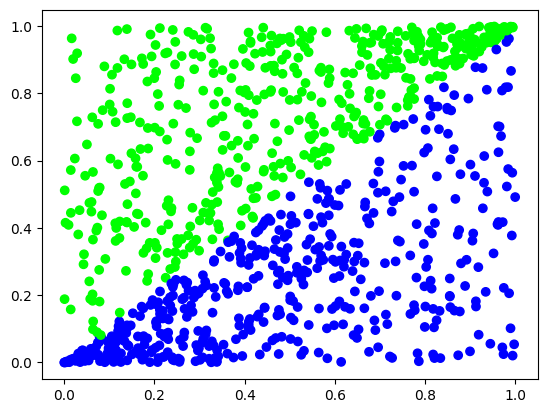

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=[[0, 1-Y[i, 0], Y[i, 0]] for i in range(1000)])
plt.show()

train - validation split

In [5]:
split = int(X.shape[0] * 0.9)

train_X, valid_X = X[:split, :], X[split:, :]
train_Y, valid_Y = Y[:split, :], Y[split:, :]

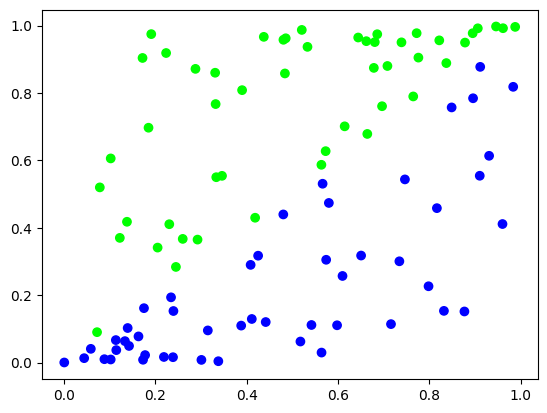

In [6]:
plt.scatter(valid_X[:, 0], valid_X[:, 1], c=[[0, 1-valid_Y[i, 0], valid_Y[i, 0]] for i in range(valid_X.shape[0])])
plt.show()

## Basic Neural Network

In [7]:
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import Dense

input_params = train_X.shape[1]

model = Sequential()
model.add(Dense(input_params, input_shape=(input_params, ), activation='relu', 
                kernel_initializer='random_uniform',bias_initializer='zeros'))
model.add(Dense(3, activation='relu', kernel_initializer='random_uniform',
                bias_initializer='zeros'))
model.add(Dense(1, activation='sigmoid', kernel_initializer='random_uniform',
                bias_initializer='zeros'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
input_params

2

fitting

In [8]:
model.fit(train_X, train_Y, epochs=10,
          validation_data=(valid_X, valid_Y))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5026 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5136 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4948 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5314 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5105 - loss: 0.6896 - val_accuracy: 0.5000 - val_loss: 0.6872
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5215 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6821
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4970 - loss: 0.6817 - val_accuracy: 0.5000 - val_loss: 0.6752
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5208 - loss: 0.6739 - val_accuracy: 0.6200 - val_loss:

### Callback class

In [9]:
from keras.callbacks import TensorBoard

tbcb = TensorBoard(log_dir="./log")


In [10]:
class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            print(epoch + 1, logs)

In [11]:
model.fit(train_X, train_Y, epochs=300,
          batch_size = 500,
          verbose = 0,  #default: 1
          callbacks=[MyCallback()],
          validation_data=(valid_X, valid_Y))

1 {'accuracy': 0.6677777767181396, 'loss': 0.6447953581809998, 'val_accuracy': 0.6700000166893005, 'val_loss': 0.6420078873634338}
101 {'accuracy': 0.8255555629730225, 'loss': 0.5255938172340393, 'val_accuracy': 0.8399999737739563, 'val_loss': 0.5229088068008423}
201 {'accuracy': 0.9077777862548828, 'loss': 0.412433922290802, 'val_accuracy': 0.8999999761581421, 'val_loss': 0.41546836495399475}


prediction

model.predict(valid_X)

normalization

In [12]:
pred_Y = model.predict(valid_X) > 0.5


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


## Image Processing

### Preproc.

#### read files

walking on the folder

In [14]:
import os
os.listdir("trainingSet")
[len(files) for root, dirs, files in os.walk("trainingSet")]

[0, 4188, 4132, 4401, 4137, 4684, 4063, 4072, 4351, 4177, 3795]

advanced format

In [15]:
["{}: {}".format(root, len(files))
 for root, dirs, files in os.walk("trainingSet")]


['trainingSet: 0',
 'trainingSet/9: 4188',
 'trainingSet/0: 4132',
 'trainingSet/7: 4401',
 'trainingSet/6: 4137',
 'trainingSet/1: 4684',
 'trainingSet/8: 4063',
 'trainingSet/4: 4072',
 'trainingSet/3: 4351',
 'trainingSet/2: 4177',
 'trainingSet/5: 3795']

#### undersample

In [16]:
import random

In [17]:
min_len = min([len(files) for root, dirs, files in os.walk("trainingSet")][1:])
min_len

3795

In [18]:
for root, dirs, files in os.walk("trainingSet"):
    if (len(files) == 0):
        continue
    del_count = len(files)-min_len
    random.shuffle(files)
    for f in files[:del_count]:
        os.remove(os.path.join(root, f))


plot images

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

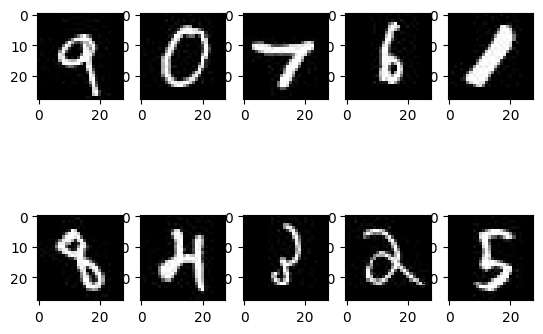

In [20]:
fig, axs = plt.subplots(2,5)
i=0
for root, dirs, files in os.walk("trainingSet"):
    if (len(files) == 0):
        continue
    axs[int(i/5)][i%5].imshow(mpimg.imread(os.path.join(root, random.choice(files))), 'gray')
    i+=1

#### ImageDataGenerator

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
train_gen = ImageDataGenerator(rescale=1./255, featurewise_std_normalization=True)

/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1063: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, which overrides setting of `featurewise_center`.
  warnings.warn(


In [24]:
train_data = train_gen.flow_from_directory("trainingSet",
                                           target_size=(28, 28),
                                           batch_size=512,
                                           color_mode='grayscale')


Found 37950 images belonging to 10 classes.


train-validation split with reshape

In [27]:
imsize = 64

train_gen = ImageDataGenerator(rescale=1./255, featurewise_std_normalization=True)
train_data = train_gen.flow_from_directory("cat-and-dog/training_set",
                                           target_size=(imsize, imsize),
                                           class_mode='binary',
                                           batch_size=128)

test_gen = ImageDataGenerator(rescale=1./255, featurewise_std_normalization=True)
test_data = train_gen.flow_from_directory("cat-and-dog/test_set",
                                          target_size=(imsize, imsize),
                                          class_mode='binary',
                                          batch_size=128)


Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


#### _summary_

In [29]:
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [61]:
min_len = min([len(files) for root, dirs, files in os.walk("trainingSet")][1:])

for root, dirs, files in os.walk("trainingSet"):
    if (len(files) == 0):
        continue
    del_count = len(files)-min_len
    random.shuffle(files)
    for f in files[:del_count]:
        os.remove(os.path.join(root, f))

["{}: {}".format(root, len(files))
 for root, dirs, files in os.walk("trainingSet")]

['trainingSet: 0',
 'trainingSet/9: 3795',
 'trainingSet/0: 3795',
 'trainingSet/7: 3795',
 'trainingSet/6: 3795',
 'trainingSet/1: 3795',
 'trainingSet/8: 3795',
 'trainingSet/4: 3795',
 'trainingSet/3: 3795',
 'trainingSet/2: 3795',
 'trainingSet/5: 3795']

In [62]:
train_gen = ImageDataGenerator(
    rescale=1./255, featurewise_std_normalization=True)
train_data = train_gen.flow_from_directory("trainingSet",
                                           target_size=(28, 28),
                                           batch_size=512,
                                           color_mode='grayscale')


Found 37950 images belonging to 10 classes.


### Models


- Az alábbiakban bináris klasszifikátort készítünk, ahol kutyák és macskák képek alapján történő klasszifikálására tanítunk be egy modellt. Ebben a megoldásban az eddig tanultakat fogjuk alkalmazni: egy egyszerű előrecsatolt hálózatot, szigmoid aktivációjú kimenettel, a bemeneti paraméterek pedig ImageDataGenerator objektumból érkeznek.

- Oldjuk meg ugyanazt a problémát konvolúciós neurális hálózatokkal! Első körben a képek mérete legyen a korábban használt $48 \times 48$, így jól összehasonlítható lesz a megoldás a korábbival. A *batch_size* értékét nyugodtan magasabbra állíthatjuk amennyiben GPUt is használunk a tanításhoz: be fog férni a memóriájába.

- Megvizsgáltuk tehát hogy a konvolúciós architektúrák kisebb paraméterszámmal ugyanakkor nagyobb teljesítménnyel, tehát szignifikánsan jobb hatékonysággal működnek képi klasszifikáció esetén mint a teljesen összekötött rétegekből készített neurális hálózatok.
Felmerülhet kérdésként, hogy mi az ideális architektúra egy adott probléma megoldására: erre azonban nem könnyű felelni, ugyanis függ az adatok eloszlásától, mennyiségétől, felbontásától, a képek minőségétől, és a sort hosszan lehet folytatni...
Az elmúlt évek során többféle struktúrát publikáltak a kutatók, ezekből néhány általános ökölszabályt figyelhetünk meg, melyeket korábban alkalmaztunk is: Pooling esetén a maximális érték használata célszerű, ReLU aktivációk mellett, a konvolúciós kernelek mérete legyen lehetőség szerint minél kisebb, a filterszám pedig a mélyebb rétegekben lehetőség szerint egyre növekedjen.
Felmerülhet ötletként, hogy esetleg egy ismert architektúrát használjunk fel, például a korábban bemutatott ILSVRC díjnyertes modelljei alapján.

- A hatékonyság növeléséhez célszerű lehet a tanítóminták számát drasztikusan növelni -- ha ez nem lehetséges, akkor más megoldásokhoz célszerű folyamodni. Például kipróbálhatunk több a feladatnak dedikált architektúrát, majd a hiperparaméterek optimális megválasztásával mozdulhatunk jobb és jobb megoldások felé.
Egy további irány, ha felhasználunk korábbi eredményeket: kutyák és macskák megkülönböztetésével foglalkozunk, akkor esetleg felhasználhatunk olyan képi klasszifikációhoz kapcsolódó eredményeket, amelyek nem kifejezetten kutyákhoz és macskákhoz kapcsolódnak.
Innen ered a *transfer learning* ötlete: vegyünk egy betanított neurális hálózatot, amely valamely nagy, általános probléma megoldására képes. A tanításához a nekünk rendelkezésre álló adatoknál nagyságrendileg több minta állt rendelkezésre.
Elemezzük, hogy *"mit lát"* a konvolúciós hálózat: mire aktiválnak a felső rétegek, és mire aktiválnak a mélyebb rétegek? Azt figyelhetjük meg, hogy a felső rétegek általános, alacsony szintű képi jellemzőket keresnek: éleket, csúcsokat. Mélyebb réteget ezekből az egyszerűbb formákból felépített összetett jellemzőkre aktiválnak. Az ideális macskadetektor *macskákra* aktivál, de ennek egyszerűbb elemei a macska fülei vagy a szemei: ideális esetben ilyen, az egyes kategóriákra jellemző *feature*ket keresnek a konvolúciós filterek.
Legyen az a feltételezésünk, hogy az egyszerű jellemzőket nem szükséges kutyákra és macskákra specializálni, általában digitális fényképek esetén vett jellemzők megfelelőek lehetnek. Amennyiben a megoldást kutyákra és macskákra akarjuk kihegyezni, akkor a mélyebb rétegek esetén szükséges csak tanítanunk. Tehát elindulhatnánk egy olyan irányba, ahol egy klasszikus hálózatot veszük, betöltjük például az ImageNet ILSVRC 1000 kategoriájához tartozó súlyparamétereket, és csak a *mély* rétegek tanításával foglalkozunk! 


#### Basic Neural Network

A tanítás összefoglalva:
- sokáig tart
- a modell lassan konvergál a globális optimum felé
- sokáig tart
- és tényleg nagyon sokáig tart

A tanítás lassúságát a nagy paraméterszám okozza, amely a nagy neuronszámú teljesen összekötött rétegek hatása.

A lassú konvergencia problémáját egyrészt az okozza hogy a bemeneti paraméterek között nem lát összefüggést a modell, miközben azok szomszédosan elhelyezkedő pixelek. A szomszédsági információt fel kellene használni! A probléma másik oldala a kis méretű kép, hiszen lekicsinyítést követően információt vesztettünk. Ha nagyobb méretű képeket használnánk, a paraméterek száma, és ezáltal a modell mérete is növekedne.

In [33]:
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import Dense, Reshape
from keras.layers import LeakyReLU

In [34]:
model = Sequential()
model.add(Reshape((784, ), input_shape=(28, 28, 1)))
model.add(Dense(784, input_shape=(784, )))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(500))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(500))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(200))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(200))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(50))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(50))
model.add(LeakyReLU(alpha=0.3))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,950 (5.39 MB)

 Trainable params: 1,411,950 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from keras.layers import Dropout

In [38]:
param_num = imsize*imsize*3


model = Sequential()
model.add(Reshape((param_num, ), input_shape=(imsize, imsize, 3)))
model.add(Dense(4000, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(4000, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(400, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(400, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [41]:
model.fit(train_data,
                    epochs=20)


/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1273: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/20


/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 716ms/step - accuracy: 0.4978 - loss: 4.1596
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 589ms/step - accuracy: 0.5058 - loss: 0.6950
Epoch 3/20
28/63 ━━━━━━━━━━━━━━━━━━━━ 22s 643ms/step - accuracy: 0.5323 - loss: 0.6873

KeyboardInterrupt: 

#### CNN

A modell az előző, nem konvolúciós struktúrához képest jelentős mértékben javult:
- a tanítás folyamata sokkal rövidebb, egy epoch lényegesen rövidebb ideig tart
- a konvergencia sokkal meredekebb görbét mutat: gyakorlatilag néhány epoch alatt $70%$ feletti a tanítási pontosság, gyakorlatilag $~20$ epoch után $90%$ feletti a tanítási pontosság. Persze a validációs adathalmazon mért pontosság a konkrét mérőszám, de a *training accuracy* meredek emelkedése nagyszerűen jelzi hogy a modell tanul.

Ez utóbbi pedig azt jelenti hogy inkább az overfitting problémájával kell foglalkozni, mint a nagy paraméterszámmal és lassú konvergenciával.

In [63]:
from keras import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Flatten, Dropout, Dense

In [67]:
model = Sequential()
model.add(Convolution2D(32, (5, 5),
                        input_shape=(64, 64, 3),
                        activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Convolution2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │     2,769,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825,418 (10.78 MB)

 Trainable params: 2,825,418 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 26, 26, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │     2,769,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825,418 (10.78 MB)

 Trainable params: 2,825,418 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.fit(train_data, epochs=20)

Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d_18" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (None, 28, 28, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 28, 28, 1), dtype=float32)
  • training=True
  • mask=None

In [70]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define your model
model = Sequential()
model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile your model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Create an ImageDataGenerator for preprocessing and loading training data
train_gen = ImageDataGenerator(rescale=1./255, featurewise_std_normalization=True)
train_data = train_gen.flow_from_directory("trainingSet",
                                           target_size=(28, 28),
                                           batch_size=512,
                                           color_mode='grayscale',
                                           class_mode='categorical')

# Fit the model with the training data
model.fit(train_data, epochs=20)


/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1063: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, which overrides setting of `featurewise_center`.
  warnings.warn(


Found 37950 images belonging to 10 classes.


/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/legacy/preprocessing/image.py:1273: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/20


/Users/banoczymartin/Projects/notes/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step - accuracy: 0.6457 - loss: 1.1104
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.9512 - loss: 0.1592
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.9717 - loss: 0.0954
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.9781 - loss: 0.0729
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9823 - loss: 0.0603
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9825 - loss: 0.0532
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.9864 - loss: 0.0444
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.9883 - loss: 0.0385
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9900 - loss: 0.0329
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9895 - loss: 0.0324
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.9909 - loss: 0.0283
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 223ms/ste

#### VGG-16

134 million params.

In [71]:
from keras.applications.vgg16 import VGG16

In [72]:
model = VGG16(include_top=True, weights=None, classes=1)
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

#### MobileNetV2

2 million params.
for multiple classes

In [73]:
from keras.applications.mobilenet_v2 import MobileNetV2

In [74]:
model = MobileNetV2(include_top=True, weights=None, classes=1)
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 2,225,153 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

for binary classification

In [75]:
from keras.activations import sigmoid

model.layers[-1].activation = sigmoid


In [76]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


#### Transfer Learning
MobileNetV2

2 million params.
for multiple classes


A hatékonyság növeléséhez célszerű lehet a tanítóminták számát drasztikusan növelni -- ha ez nem lehetséges, akkor más megoldásokhoz célszerű folyamodni. Például kipróbálhatunk több a feladatnak dedikált architektúrát, majd a hiperparaméterek optimális megválasztásával mozdulhatunk jobb és jobb megoldások felé.

Egy további irány, ha felhasználunk korábbi eredményeket: kutyák és macskák megkülönböztetésével foglalkozunk, akkor esetleg felhasználhatunk olyan képi klasszifikációhoz kapcsolódó eredményeket, amelyek nem kifejezetten kutyákhoz és macskákhoz kapcsolódnak.

Innen ered a *transfer learning* ötlete: vegyünk egy betanított neurális hálózatot, amely valamely nagy, általános probléma megoldására képes. A tanításához a nekünk rendelkezésre álló adatoknál nagyságrendileg több minta állt rendelkezésre.

Elemezzük, hogy *"mit lát"* a konvolúciós hálózat: mire aktiválnak a felső rétegek, és mire aktiválnak a mélyebb rétegek? Azt figyelhetjük meg, hogy a felső rétegek általános, alacsony szintű képi jellemzőket keresnek: éleket, csúcsokat. Mélyebb réteget ezekből az egyszerűbb formákból felépített összetett jellemzőkre aktiválnak. Az ideális macskadetektor *macskákra* aktivál, de ennek egyszerűbb elemei a macska fülei vagy a szemei: ideális esetben ilyen, az egyes kategóriákra jellemző *feature*ket keresnek a konvolúciós filterek.

Legyen az a feltételezésünk, hogy az egyszerű jellemzőket nem szükséges kutyákra és macskákra specializálni, általában digitális fényképek esetén vett jellemzők megfelelőek lehetnek. Amennyiben a megoldást kutyákra és macskákra akarjuk kihegyezni, akkor a mélyebb rétegek esetén szükséges csak tanítanunk. Tehát elindulhatnánk egy olyan irányba, ahol egy klasszikus hálózatot veszük, betöltjük például az ImageNet ILSVRC 1000 kategoriájához tartozó súlyparamétereket, és csak a *mély* rétegek tanításával foglalkozunk!

In [77]:
from keras.models import Model
from keras.layers import Dense
from keras.applications.mobilenet_v2 import MobileNetV2

In [78]:
model = MobileNetV2(include_top=True, weights='imagenet', classes=1000)
model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [79]:
for l in model.layers[:113]:
    l.trainable = False

1000 softmaxed dense -> 1 sigmoided dense

In [80]:

penultimate = model.layers[-2]
newultimate = Dense(1, activation='sigmoid')(penultimate.output)

newmodel = Model(inputs=model.input, outputs=newultimate)
newmodel.summary()
model = newmodel


Model: "functional_126"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,738,113 (6.63 MB)

 Non-trainable params: 521,152 (1.99 MB)

In [81]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


## Idősoros adatok

#### some plots

In [95]:
import matplotlib.pyplot as plt
def plot_history(history):
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [1000$]')
  plt.plot(history.epoch, np.array(history.history['mae']), 
           label='Train')
  plt.plot(history.epoch, np.array(history.history['val_mae']),
           label = 'Val')
  plt.legend()
  plt.ylim([0,max(history.history['val_mae'])])

def plot_prediction(test_labels, test_predictions):
  plt.figure()
  plt.scatter(test_labels, test_predictions)
  plt.xlabel('True Values [1000$]')
  plt.ylabel('Predictions [1000$]')
  plt.axis('equal')
  plt.xlim(plt.xlim())
  plt.ylim(plt.ylim())
  _ = plt.plot([-100, 100],[-100,100])

  plt.figure()
  error = test_predictions - test_labels
  plt.hist(error, bins = 50)
  plt.xlabel("Prediction Error [1000$]")
  _ = plt.ylabel("Count")

#### import

In [96]:
import tensorflow as tf
from tensorflow import keras

import numpy as np

In [97]:
boston_housing = tf.keras.datasets.boston_housing
(train_data, train_labels), (test_data, test_labels) = boston_housing.load_data()

print("Training set: {}".format(train_data.shape))  # 404 examples, 13 features
print("Testing set:  {}".format(test_data.shape))   # 102 examples, 13 features
print(train_data[0])

Training set: (404, 13)
Testing set:  (102, 13)
[  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]


In [98]:
import pandas as pd

column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
                'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(train_data, columns=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


#### normalizing features

In [99]:
# Test data is *not* used when calculating the mean and std.
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
train_data = (train_data - mean) / std
test_data = (test_data - mean) / std

print(train_data[0])  #

[-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
  0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
  0.8252202 ]


### Models

##### MLP (multi-layer perceptron)

In [100]:
def build_model():
  model = keras.Sequential([
    keras.layers.Input(shape=(train_data.shape[1],)),                  
    keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dense(1)
  ], name="MLP_model")

  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae'])
  return model

model = build_model()
model.summary()

Model: "MLP_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            print(epoch, logs)

In [107]:
EPOCHS = 500
# Store training stats
history = model.fit(train_data, train_labels, epochs=EPOCHS,
                    validation_split=0.2, verbose=0, callbacks=[MyCallback()])

0 {'loss': 0.5809767842292786, 'mae': 0.5431692600250244, 'val_loss': 14.878387451171875, 'val_mae': 2.661034345626831}
100 {'loss': 0.41093724966049194, 'mae': 0.4638670086860657, 'val_loss': 15.737553596496582, 'val_mae': 2.9220526218414307}
200 {'loss': 0.30240947008132935, 'mae': 0.38100001215934753, 'val_loss': 15.620593070983887, 'val_mae': 2.6780002117156982}
300 {'loss': 0.36274972558021545, 'mae': 0.42294973134994507, 'val_loss': 15.51236343383789, 'val_mae': 2.632354259490967}
400 {'loss': 0.4287050664424896, 'mae': 0.47861623764038086, 'val_loss': 17.001550674438477, 'val_mae': 2.784532308578491}


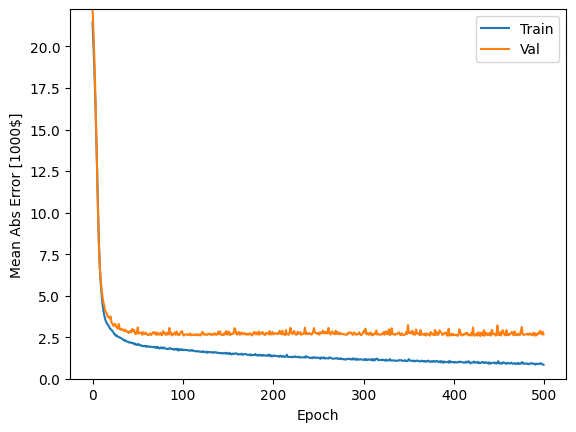

In [90]:
plot_history(history)

In [91]:
[loss, mae] = model.evaluate(test_data, test_labels, verbose=0)
print("Testing set Mean Abs Error: ${:7.2f}".format(mae * 1000))

Testing set Mean Abs Error: $23110.76


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x17f17db80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


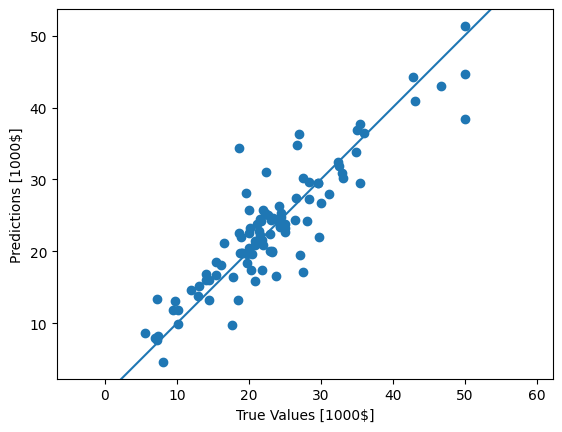

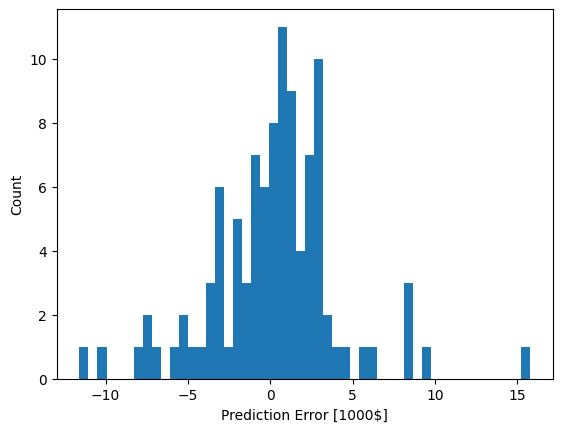

In [108]:
test_predictions = model.predict(test_data).flatten()
plot_prediction(test_labels, test_predictions)

#### Conv1D

In [109]:
print(train_data.shape)
print(train_data[0].shape)
print(train_data[0])

(404, 13)
(13,)
[-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
  0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
  0.8252202 ]


In [110]:
sample_size = train_data.shape[0] # number of samples in train set
time_steps  = train_data.shape[1] # number of features in train set
input_dimension = 1               # each feature is represented by 1 number

train_data_reshaped = train_data.reshape(sample_size,time_steps,input_dimension)
print("After reshape train data set shape:\n", train_data_reshaped.shape)
print("1 Sample shape:\n",train_data_reshaped[0].shape)
print("An example sample:\n", train_data_reshaped[0])

After reshape train data set shape:
 (404, 13, 1)
1 Sample shape:
 (13, 1)
An example sample:
 [[-0.27224633]
 [-0.48361547]
 [-0.43576161]
 [-0.25683275]
 [-0.1652266 ]
 [-0.1764426 ]
 [ 0.81306188]
 [ 0.1166983 ]
 [-0.62624905]
 [-0.59517003]
 [ 1.14850044]
 [ 0.44807713]
 [ 0.8252202 ]]


<img src="https://github.com/kmkarakaya/ML_tutorials/blob/master/images/conv1d.gif?raw=true" width="500">

In [111]:
test_data_reshaped = test_data.reshape(test_data.shape[0],test_data.shape[1],1)

In [112]:
def build_conv1D_model():

  n_timesteps = 13#train_data_reshaped.shape[1] #13
  n_features  =1# train_data_reshaped.shape[2] #1 
  model = keras.Sequential(name="model_conv1D")
  model.add(keras.layers.Input(shape=(n_timesteps,n_features)))
  model.add(keras.layers.Conv1D(filters=128, kernel_size=7, activation='relu', name="Conv1D_1"))
  model.add(keras.layers.Dropout(0.5))
  model.add(keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', name="Conv1D_2"))
  
  model.add(keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', name="Conv1D_3"))
  
  model.add(keras.layers.MaxPooling1D(pool_size=2, name="MaxPooling1D"))
  model.add(keras.layers.Flatten())
  model.add(keras.layers.Dense(64, activation='relu', name="Dense_1"))
  model.add(keras.layers.Dense(n_features, name="Dense_2"))


  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(loss='mse',optimizer=optimizer,metrics=['mae'])
  return model

model_conv1D = build_conv1D_model()
model_conv1D.summary()

Model: "model_conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1D_1 (Conv1D)               │ (None, 7, 128)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 5, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_3 (Conv1D)               │ (None, 3, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling1D (MaxPooling1D)     │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,017 (132.88 KB)

 Trainable params: 34,017 (132.88 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# Store training stats
history = model_conv1D.fit(train_data_reshaped, train_labels, epochs=EPOCHS,
                    validation_split=0.2, verbose=1)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 499.7973 - mae: 20.4135 - val_loss: 183.7620 - val_mae: 10.7726
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 123.9388 - mae: 8.6871 - val_loss: 101.2282 - val_mae: 7.3252
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70.5454 - mae: 6.3041 - val_loss: 81.2183 - val_mae: 6.8658
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.5745 - mae: 5.6455 - val_loss: 86.4334 - val_mae: 6.7704
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.6123 - mae: 5.0270 - val_loss: 61.8564 - val_mae: 5.7145
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.5266 - mae: 4.6761 - val_loss: 70.8057 - val_mae: 5.9617
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49.6914 - mae: 4.9520 - val_loss: 46.9607 - val_mae: 4.7321
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.1619 - mae: 4.7799 - val_loss: 55.4582 - val_mae: 5.0329
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
plot_history(history)
[loss, mae] = model_conv1D.evaluate(test_data_reshaped, test_labels, verbose=0)
print("Testing set Mean Abs Error: ${:7.2f}".format(mae * 1000))
test_predictions = model_conv1D.predict(test_data_reshaped).flatten()
plot_prediction(test_labels, test_predictions)

## Recurrent networks

### plots and imports

In [ ]:
import pandas as pd

df = pd.read_csv('jena_climate_2009_2016.csv')
df.drop(['Date Time'], axis=1, inplace=True)
df.head()

In [ ]:
from matplotlib import pyplot as plt

temp = df['T (degC)'].values
plt.plot(range(temp.shape[0]), temp)
plt.show()

In [ ]:
temp = df['T (degC)'].values[:6*24]
plt.plot(range(temp.shape[0]), temp)
plt.title('A hőmérséklet 2009. január 1-én')
plt.show()

In [ ]:
temp = df['T (degC)'].values[:6*24*31]
plt.plot(range(temp.shape[0]), temp)
plt.title('A hőmérséklet 2009. január hónapban')
plt.show()

temp = df['T (degC)'].values[:6*24*365]
plt.plot(range(temp.shape[0]), temp)
plt.title('A hőmérséklet 2009. évben')
plt.show()

In [ ]:
data = df.values
data.shape

In [ ]:
train_limit = 200000
validation_limit = 300000
test_limit = data.shape[0]

mean = data[:train_limit].mean(axis=0)
data -= mean
std = data[:train_limit].std(axis=0)
data /= std

### generator function

A kimenet egy `(samples, targets)` tuple, ahol a `samples` egy kötegnyi bemeneti paramétert tartalmaz, a `targets` pedig az ehhez tartozó elvárt értékeket. A szükséges bemeneti paraméterek:

* `data`: a bemeneti tömb
* `lookback`: az időablak mérete
* `delay`: hány lépéssel későbbi megfigyelést szeretnénk prediktálni
* `min_index` és `max_index`: A `data` tömb releváns elemeinek kijelölése a részhalmazok szeparálására
* `shuffle`: összekeverhetőek-e a mintáink, vagy időrendi sorban haladjon
* `batch_size`: a kötegenkénti minták száma
* `step`: a mintavételezés lépésszáma
* `target_idx`: a prediktálni szándékozott változó indexe a tömbben

In [ ]:
def generator(data, lookback, delay, min_index, max_index,
              shuffle=False, batch_size=128, step=1, target_idx=1):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while 1:
        if shuffle:
            rows = np.random.randint(
                min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)

        samples = np.zeros((len(rows),
                           lookback // step,
                           data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices]
            targets[j] = data[rows[j] + delay][target_idx]
        yield samples, targets

In [ ]:
lookback = 5 * 24 * 6            # 5 napnyi adat
step = 6                         # óránként egy mintavételezés
delay = 1 * 24 * 6               # 1 nappal későbbi predikció
batch_size = 128

train_gen = generator(data,
                      lookback=lookback,
                      delay=delay,
                      min_index=0,
                      max_index=train_limit,
                      shuffle=True,
                      step=step, 
                      batch_size=batch_size)
val_gen = generator(data,
                    lookback=lookback,
                    delay=delay,
                    min_index=train_limit + 1,
                    max_index=validation_limit,
                    step=step,
                    batch_size=batch_size)
test_gen = generator(data,
                     lookback=lookback,
                     delay=delay,
                     min_index=validation_limit + 1,
                     max_index=None,
                     step=step,
                     batch_size=batch_size)

train_steps = (train_limit  - lookback) // batch_size
val_steps = (validation_limit - (train_limit + 1) - lookback) // batch_size
test_steps = (test_limit - (validation_limit + 1) - lookback) // batch_size

### Models

#### 0. solution

*Naívan*, józan ésszel gondolkodva, mindenféle gépi tanulási módszer elkészíthetünk egy feltételezhetően jól működő predikciós eszközt az elérhető adatok alapján: mondhatjuk azt, hogy egy adott időpillanatra várt hőmérséklet közel lesz az előző nap ugyanazon pillanatában mért hőmérséklethez.

In [ ]:
import numpy as np

batch_maes = []
for s in range(test_steps):
    samples, targets = next(test_gen)
    preds = samples[:, -1, 1]
    mae = np.mean(np.abs(preds - targets))
    batch_maes.append(mae)
print(np.mean(batch_maes))

Mivel a szórással normalizáltuk az eredményt, így szükséges azzal visszaszorozni hogy a Celsius-skála szerinti értéket kapjunk:

In [ ]:
np.mean(batch_maes) * std[1]  # a df második oszlopa volt a hőmérséklet

#### 1. solution, classic neural network

In [ ]:
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential()
model.add(Flatten(input_shape=(lookback // step, data.shape[-1])))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mae')

es = EarlyStopping(patience=50)
checkpoint_filepath = 'dense_model_best.h5'
mc = ModelCheckpoint(filepath=checkpoint_filepath,
                     save_weights_only=True,
                     monitor='val_loss',
                     mode='min',
                     save_best_only=True)

hist = model.fit_generator(train_gen,
                           steps_per_epoch=train_steps,
                           epochs=500,
                           validation_data=val_gen,
                           validation_steps=val_steps,
                           callbacks=[es, mc])

In [ ]:
import matplotlib.pyplot as plt

loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()

plt.show()

In [ ]:
model.load_weights(checkpoint_filepath)
test_acc = model.evaluate_generator(test_gen, steps=test_steps, verbose=0)

In [ ]:
test_acc

In [ ]:
batch_maes = []
for r in range(train_steps):
    samples, targets = next(train_gen)
    preds = model.predict(samples)
    mae = np.mean(np.abs(preds - targets))
    batch_maes.append(mae)
print(np.mean(batch_maes))

In [ ]:
batch_maes = []
for r in range(val_steps):
    samples, targets = next(val_gen)
    preds = model.predict(samples)
    mae = np.mean(np.abs(preds - targets))
    batch_maes.append(mae)
print(np.mean(batch_maes))

In [ ]:
batch_maes = []
for r in range(test_steps):
    samples, targets = next(test_gen)
    preds = model.predict(samples)
    mae = np.mean(np.abs(preds - targets))
    batch_maes.append(mae)
print(np.mean(batch_maes))

In [ ]:
test_acc * std[1]

#### 2. solution: recurrent network

In [ ]:
from keras.layers import SimpleRNN

model = Sequential()
model.add(SimpleRNN(32, input_shape=(None, data.shape[-1])))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mae')

es = EarlyStopping(patience=5)
checkpoint_filepath = 'simplernn_model_best.h5'
mc = ModelCheckpoint(filepath=checkpoint_filepath,
                     save_weights_only=True,
                     monitor='val_loss',
                     mode='min',
                     save_best_only=True)

hist = model.fit_generator(train_gen,
                           steps_per_epoch=train_steps,
                           epochs=500,
                           validation_data=val_gen,
                           validation_steps=val_steps,
                           callbacks=[es, mc])

In [ ]:
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()

plt.show()

In [ ]:
model.evaluate_generator(test_gen, steps=test_steps, verbose=0) * std[1]

#### 3. solution: stacked LSTM layers with dropout regularization

In [ ]:
from keras.layers import LSTM

model = Sequential()
model.add(LSTM(32,
               dropout=0.1,
               recurrent_dropout=0.2,
               return_sequences=True,
               input_shape=(None, data.shape[-1])))
model.add(LSTM(64, 
               activation='relu',
               dropout=0.1, 
               recurrent_dropout=0.2))
model.add(Dense(1))

model.compile('sgd', loss='mae')
es = EarlyStopping(patience=5)
checkpoint_filepath = 'stacked_lstm_model_best.h5'
mc = ModelCheckpoint(filepath=checkpoint_filepath,
                     save_weights_only=True,
                     monitor='val_loss',
                     mode='min',
                     save_best_only=True)

history = model.fit_generator(train_gen,
                              steps_per_epoch=train_steps,
                              epochs=500,
                              validation_data=val_gen,
                              validation_steps=val_steps,
                              callbacks=[es, mc])

In [ ]:
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()

plt.show()

In [ ]:
model.evaluate_generator(test_gen, steps=test_steps, verbose=0) * std[1]

### Simple RNN

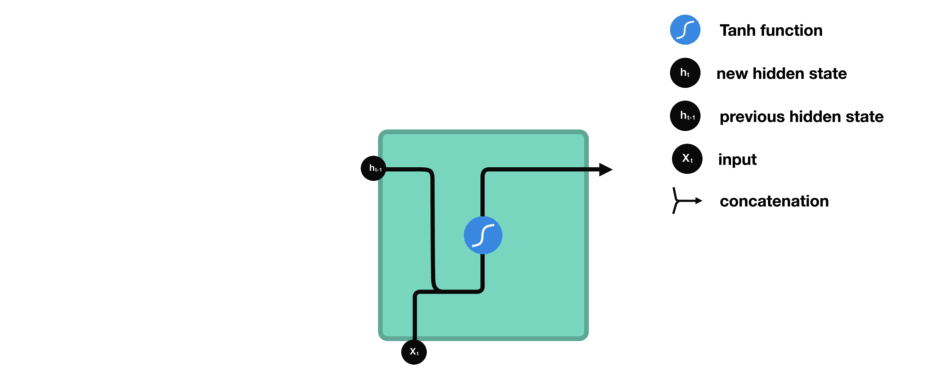

In [ ]:

from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

In [ ]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, 
                        activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

demo_model = create_RNN(2, 1, (3,1), activation=['linear', 'linear'])

In [ ]:
wx = demo_model.get_weights()[0]
wh = demo_model.get_weights()[1]
bh = demo_model.get_weights()[2]
wy = demo_model.get_weights()[3]
by = demo_model.get_weights()[4]

print('wx = ', wx, ' wh = ', wh, ' bh = ', bh, ' wy =', wy, 'by = ', by)

In [ ]:
x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features 
x_input = np.reshape(x,(1, 3, 1))
y_pred_model = demo_model.predict(x_input)


m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + h0 + bh
h2 = np.dot(x[1], wx) + np.dot(h1,wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2,wh) + bh
o3 = np.dot(h3, wy) + by

print('h1 = ', h1,'h2 = ', h2,'h3 = ', h3)

print("Prediction from network ", y_pred_model)
print("Prediction from our computation ", o3)

In [ ]:
# Parameter split_percent defines the ratio of training examples
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

In [ ]:
# Prepare the input X and target Y
def get_XY(dat, time_steps):
    # Indices of target array
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    # Prepare X
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))    
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)




In [ ]:
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), 
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

In [ ]:
def print_error(trainY, testY, train_predict, test_predict):    
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))    

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

In [ ]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plot_result(trainY, testY, train_predict, test_predict)

In [ ]:
# Parameter split_percent defines the ratio of training examples
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

# Prepare the input X and target Y
def get_XY(dat, time_steps):
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))    
    return X, Y

def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

def print_error(trainY, testY, train_predict, test_predict):    
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))    

# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
time_steps = 12
train_data, test_data, data = get_train_test(sunspots_url)
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# Create model and train
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), 
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Print error
print_error(trainY, testY, train_predict, test_predict)

#Plot result
plot_result(trainY, testY, train_predict, test_predict)

## LSTM & GRU

#### imports

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

#### plots

In [ ]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

In [ ]:
# First, we get the data
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

In [ ]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values


In [ ]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

#### scaling

In [ ]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

#### LSTM Model

In [ ]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=5,batch_size=32)

In [ ]:
# Now to get the test set ready in a similar way as the training set.
# The following has been done so forst 60 entires of test set have 60 previous values which is impossible to get unless we take the whole 
# 'High' attribute data for processing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

In [ ]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

In [ ]:
# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

In [ ]:
# Evaluating our model
return_rmse(test_set,predicted_stock_price)

#### GRU Model

In [ ]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))
# Compiling the RNN
regressorGRU.compile(optimizer=SGD(lr=0.01, decay=1e-7, momentum=0.9, nesterov=False),loss='mean_squared_error')
# Fitting to the training set
regressorGRU.fit(X_train,y_train,epochs=50,batch_size=150)

In [ ]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

In [ ]:
# Visualizing the results for GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [ ]:
# Evaluating GRU
return_rmse(test_set,GRU_predicted_stock_price)

In [ ]:
# Preparing sequence data
initial_sequence = X_train[2708,:]
sequence = []
for i in range(251):
    new_prediction = regressorGRU.predict(initial_sequence.reshape(initial_sequence.shape[1],initial_sequence.shape[0],1))
    initial_sequence = initial_sequence[1:]
    initial_sequence = np.append(initial_sequence,new_prediction,axis=0)
    sequence.append(new_prediction)
sequence = sc.inverse_transform(np.array(sequence).reshape(251,1))

In [ ]:
# Visualizing the sequence
plot_predictions(test_set,sequence)

#### LSTM types

In [ ]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional,TimeDistributed,Conv1D,ConvLSTM2D
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
lista = [10, 20, 30, 40, 50, 60, 70, 80, 90]

In [ ]:
# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the sequence
		if end_ix > len(sequence)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [ ]:
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

##### Vanilla LSTM

In [ ]:
...
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [ ]:

# define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [ ]:
model.fit(X, y, epochs=200, verbose=0)

In [ ]:
# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)

In [ ]:
# univariate lstm example
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=200, verbose=0)
# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### Stacked LSTM

In [ ]:
...
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [ ]:
# univariate stacked lstm example
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=200, verbose=0)
# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### Bidirectional LSTM

In [ ]:
...
# define model
model = Sequential()
model.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [ ]:
# univariate bidirectional lstm example
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Bidirectional


# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))
# define model
model = Sequential()
model.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=200, verbose=0)
# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### CNN LSTM

In [ ]:
...
# choose a number of time steps
n_steps = 4
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, subsequences, timesteps, features]
n_features = 1
n_seq = 2
n_steps = 2
X = X.reshape((X.shape[0], n_seq, n_steps, n_features))

In [ ]:
...
model.add(TimeDistributed(Conv1D(filters=64, kernel_size=1, activation='relu'), input_shape=(None, n_steps, n_features)))
model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
model.add(TimeDistributed(Flatten()))

In [ ]:
# univariate cnn lstm example
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import TimeDistributed
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D

# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 4
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, subsequences, timesteps, features]
n_features = 1
n_seq = 2
n_steps = 2
X = X.reshape((X.shape[0], n_seq, n_steps, n_features))
# define model
model = Sequential()
model.add(TimeDistributed(Conv1D(filters=64, kernel_size=1, activation='relu'), input_shape=(None, n_steps, n_features)))
model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
model.add(TimeDistributed(Flatten()))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=500, verbose=0)
# demonstrate prediction
x_input = array([60, 70, 80, 90])
x_input = x_input.reshape((1, n_seq, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### Conv. LSTM

In [ ]:
...
# choose a number of time steps
n_steps = 4
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, rows, columns, features]
n_features = 1
n_seq = 2
n_steps = 2
X = X.reshape((X.shape[0], n_seq, 1, n_steps, n_features))

In [ ]:
...
model.add(ConvLSTM2D(filters=64, kernel_size=(1,2), activation='relu', input_shape=(n_seq, 1, n_steps, n_features)))
model.add(Flatten())

In [ ]:
# univariate convlstm example
from numpy import array
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import ConvLSTM2D

# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 4
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, rows, columns, features]
n_features = 1
n_seq = 2
n_steps = 2
X = X.reshape((X.shape[0], n_seq, 1, n_steps, n_features))
# define model
model = Sequential()
model.add(ConvLSTM2D(filters=64, kernel_size=(1,2), activation='relu', input_shape=(n_seq, 1, n_steps, n_features)))
model.add(Flatten())
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=500, verbose=0)
# demonstrate prediction
x_input = array([60, 70, 80, 90])
x_input = x_input.reshape((1, n_seq, 1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### Multivariate LSTM Models

In [ ]:
...
# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])

In [ ]:
...
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [ ]:
# multivariate data preparation
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
print(dataset)

In [ ]:
# multivariate data preparation
from numpy import array
from numpy import hstack

# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
print(X.shape, y.shape)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

In [ ]:
...
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [ ]:
...
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)

In [ ]:
# multivariate lstm example
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
# the dataset knows the number of features, e.g. 2
n_features = X.shape[2]
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=200, verbose=0)
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

##### multiple parallel series

In [ ]:
# multivariate output data prep
from numpy import array
from numpy import hstack

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix, :]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
print(X.shape, y.shape)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

In [ ]:
...
# define model
model = Sequential()
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(100, activation='relu'))
model.add(Dense(n_features))
model.compile(optimizer='adam', loss='mse')

In [ ]:
...
# demonstrate prediction
x_input = array([[70,75,145], [80,85,165], [90,95,185]])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)

In [ ]:
# multivariate output stacked lstm example
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
# the dataset knows the number of features, e.g. 2
n_features = X.shape[2]
# define model
model = Sequential()
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(100, activation='relu'))
model.add(Dense(n_features))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=400, verbose=0)
# demonstrate prediction
x_input = array([[70,75,145], [80,85,165], [90,95,185]])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

## NLP (Natural Language Processing)
task: text generation

### RNN using characters as tokens

Az alábbi feladatban egy egyszerű példát tekintünk szöveganalízisre: neurális hálózattal elemzünk egy szöveget karakterenként, *soros* adatként értelmezve a karakterek egymásutániságát, prediktálva egy ablaknyi szöveget követő következő karaktert. Egy modellt *túlillesztünk* egy hosszabb szövegen, majd szöveget próbálunk generáltatni általa, újabb és újabb karaktereket becsülve egy megadott bemenetre.

In [ ]:
import sys
import numpy as np
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import InputLayer
from keras.layers import SimpleRNN, Dense, GRU, LSTM, Conv1D, Dropout
from keras.utils import np_utils

Több mintafilet is mellékelek a megoldáshoz: a több adat nyilván nagyobb pontosságot tud elhozni. A magyar szövegek esetén a ragozás környékén nagy pontatlanságot fedezhetünk majd fel.

Javasolt többet is kipróbálni!

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "ezután azt felelte neki a jános "
bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

Az egyedi karakterek kigyűjtését a szöveg halmazzá(*set*) alakításával kezdjük, majd ez listává alakítjuk, és abc-sorrendbe rendezzük.

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()

chars = sorted(list(set(szoveg)))

print("karakterek: ", chars)

In [ ]:
char_to_int = dict((c, i) for i,c in enumerate(chars))
int_to_char = dict((i, c) for i,c in enumerate(chars))

print(char_to_int)
print(int_to_char)

hossz = len(szoveg)
karakterszam = len(chars)
windowsize = 32

print("hossz: ", hossz)
print("karakterek szama: ", karakterszam)
print("ablakmeret: ", windowsize)

A megállapított ablakméretet véve létrehozzuk a szöveg alapján a tanítómintákat: minden esetben a 32 karakter hosszú blokk alkotja az egyes mintát, a hozzá tartozó címkét pedig az ablakot követő 33. karakter.

In [ ]:
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szoveg[i : i+windowsize]
    kov = szoveg[i+windowsize]
    # print(tmp, kov)
    dataX.append([char_to_int[c] for c in tmp])
    dataY.append(char_to_int[kov])

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize, 1))

print("X: ", X.shape)
# print("pl: ", X[100])

In [ ]:
dataY[0:10]

Ezek persze kimenetnek nem megfelelőek, így a numerikus adatok kategorikussá kerülnek átalakításra, amely a *keras.utils.np_utils.to_categorical()* segédfüggvénnyel megtehető. (Lásd: one-hot encoding)

In [ ]:
y = np_utils.to_categorical(dataY)

In [ ]:
y[0:3]

X normalizálható, és készülhet a modell. A SimpleRNN a klasszikus rekurrens réteget ábrázolja. Ha csak egy van belőle, akkor relatíve jól működik. Ha több ilyen réteg egymásra építésével próbálkoznánk a teljesítmény növelése érdekében, akkor a mélyebben levő rétegek egyszerűen nem fognak hatékonyan tanulni: erre megoldás az LSTM vagy GRU réteg.

In [ ]:
X = X / float(karakterszam)

model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(SimpleRNN(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')

model.summary()

A *Callback* osztályból származtatva definiáljuk a *TestGen* classt, amely megadja, hogy mi történjen az egyes iterációk végén: validáció gyanánt próbáljon meg szöveget generálni a modell a korábban megadott minta alapján.

Az algoritmus dióhéjban: a minta alapján a prediktál a modell, a predikció legnagyobb értékű elemének indexe adja meg hogy mely karakter a legvalószínűbb a modell szerint, a dictionary segítségével ez hosszáfűzésre kerül az eredményhez, majd a mintához is hozzáfűzésre kerül, ledobva a korábbi első karaktert.

In [ ]:
class TestGen(Callback):
    def on_epoch_end(self, epoch, logs=None):
        #minta 32 karakter hosszú
        #minta = "queen daenerys targaryen is the ".lower()
        #minta = "ezután azt felelte neki a jános ".lower()
        minta = bevezeto.lower()
        print("\nfolytasd a mondatot: ", minta)
        pattern = [char_to_int[c] for c in minta]
        resp = ""
        for i in range(40):
            test_X = np.reshape(pattern, (1, len(pattern), 1))
            test_X = test_X / float(karakterszam)
            pred = model.predict(test_X, verbose=0)
            maxidx = np.argmax(pred)
            resp += int_to_char[maxidx]
            pattern.append(maxidx)
            pattern = pattern[1: len(pattern)]
        print(resp + "\n")

In [ ]:
model.fit(X, y, batch_size=256,
          epochs=10,
          callbacks=[TestGen()]
         )

Az gyorsan belátható, hogy a módszer bár működik, jelen formájában nem túl hatékony: esetleg több egymást követő rekurrens réteggel lehet segíteni a megoldást: ezt nevezik *stacked RNN*-nek.

In [ ]:
model.summary()

Sajnos ez sem segít jelentősen, és ennek az alacsony epochszámon túl a rekurrens rétegek egy komoly hátulütője az oka: a *vanishing gradient*.

A rekurrens hálózatok rövidtávú memóriát valósítanak meg. Persze nem ez volt a tervezéskori cél, de a működésükből (és a *backpropagation* algoritmus viselkedéséből) adódóan a régmúltban történtek egyre kevésbé lesznek relevánsak. Minél több információt dolgoznak fel a visszacsatolt elemek, egyre kevésbé képesek a korábban tárolt információk fenntartására. Erre a problémára jelenthet majd megoldást az LSTM és a GRU cella a "szimpla" rekurrens elemek helyett.

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')

In [ ]:
model.fit(X, y, batch_size=256,
          epochs=10,
          callbacks=[TestGen()]
         )

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(GRU(128, return_sequences=True))
model.add(GRU(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')

In [ ]:
model.fit(X, y, batch_size=256,
          epochs=10,
          callbacks=[TestGen()]
         )

In [ ]:
filename = "nemzetidal.txt"
#filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

bevezeto = " A magyarok istenére\nEsküszünk, "
#bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()

chars = sorted(list(set(szoveg)))

print("karakterek: ", chars)
char_to_int = dict((c, i) for i,c in enumerate(chars))
int_to_char = dict((i, c) for i,c in enumerate(chars))

print(char_to_int)
print(int_to_char)

hossz = len(szoveg)
karakterszam = len(chars)
windowsize = 32

print("hossz: ", hossz)
print("karakterek szama: ", karakterszam)
print("ablakmeret: ", windowsize)
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szoveg[i : i+windowsize]
    kov = szoveg[i+windowsize]
    # print(tmp, kov)
    dataX.append([char_to_int[c] for c in tmp])
    dataY.append(char_to_int[kov])

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize, 1))

print("X: ", X.shape)
# print("pl: ", X[100])
y = np_utils.to_categorical(dataY)


In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(SimpleRNN(128, return_sequences=True))
model.add(SimpleRNN(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(X, y, batch_size=64,
          epochs=100,
          callbacks=[TestGen()]
         )

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(X, y, batch_size=64,
          epochs=100,
          callbacks=[TestGen()]
         )

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(GRU(128, return_sequences=True))
model.add(GRU(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(X, y, batch_size=64,
          epochs=100,
          callbacks=[TestGen()]
         )

### RNN using Word Tokenization

Az előzőekben bemutatott Embedding rétegnek persze akkor van értelme, ha a bemeneti dimenziószám jelentősen nagy, nehezen kezelhető. Így kifejezetten a karakterek alapján történő feldolgozás helyett célszerű eggyel magasabb absztrakciós szint felé lépni: próbálkozzunk meg szavak egymásutánisága szerint prediktálni!

A szavak -- mivel a gyakorlatban karakterekből épülnek fel, és hosszuk nem limitált -- sokkal nagyobb számban fordulhatnak elő a bemeneti szövegekben. A továbbiakban teljesen ugyanaz lesz a feladat és a bemeneti adatok, azonban karakterek helyett szavak szerint és szavakat próbálunk meg prediktálni, ezáltal szöveget generálni.

In [ ]:
import sys
import numpy as np
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import InputLayer
from keras.layers import SimpleRNN, Dense, GRU, LSTM, Conv1D, Dropout
from keras.utils import np_utils

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "ezután azt felelte neki a jános "
#bevezeto = "a venni lélekzetet szegény János "
bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

A Keras csomagjai között elérhető a *Tokenizer*, amely segít a bemeneti szöveget szavakra bontani. Konstruktorában vár egy *filters* nevű stringet, amely karakterei ki lesznek szűrve a szöveg feldolgozása során. Jellemzően vesszők, mondatvégi írásjelek és egyéb speciális karakterek kerülhetnek ily módon kihagyásra.

Ha célunk esetleg a mondatvégi írásjelek és a vessző szöveggel együtt történő generálása is, akkor ezeket például a lentebb látható módon kihagyhatjuk -- és, hogy a felbontáskor ne kerüljenek a szóhoz *ragasztásra*, szóközzel eltolhatjuk.

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()

meghagyni = [".", ",", "?", "!"]
for c in meghagyni:
    szoveg = szoveg.replace(c, " " + c)

from keras.preprocessing.text import Tokenizer

#t = Tokenizer()
#t = Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
t = Tokenizer(filters='"#$%&()*+-/:;<=>@[\\]^_`{|}~\t\n')

A *Tokenizer* objektumon elérhető a *fit_on_texts* metódus, amely egy stringekből álló listát vár elemzésre. Elemzéskor az egyes szavak kiválogatásra kerülnek gyakoriság szerinti csökkenő sorrendben.

Megjegyzendő, hogy egy *valódi* Natural Language Processing (NLP) alkalmazásban a szavak elemzésekor esetleg a különböző ragozott változatok együtt kezelendőek, illetve a mondatban betöltött szerep is vizsgálható lehet. Az egyszerűség kedvéért ezeket a lépéseket kihagyjuk, amely persze a teljesítményre is hatással lesz.

In [ ]:
texts = [szoveg]
t.fit_on_texts(texts)

A *word_index* az a dictionary, amely szavakból egészekre képez le. Célszerű megfigyelni, hogy az indexelés 1-bázisú, a korábbi 0 helyett. Ez persze nem hiba: a nulla kitüntetett szereppel *kellene* hogy rendelkezzen, itt most nem használjuk ezt ki.

In [ ]:
t.word_index

A *word_counts* megadja az egyes szavak előfordulásának számát.

Ez a dictionary a szavak első előfordulása szerint rendezett, így Petőfi versében például megfigyelhető a *szerelem* - *szerelmemért* - *szerelmemet* szavak megkülönböztetése.

In [ ]:
t.word_counts

A *fit_on_texts* kifejezetten arra való, hogy előállítsa ezt a dictionaryt, így célszerű lenne egy hatalmas *corpuson* mintavételezni a konkrét tanító adatok helyett.

A *texts_to_sequences* metódus szolgál a bemeneti stringek *szekvenciákká*, azaz integereket tartalmazó listákká képezésére. Lévén itt egy string kerül átadásra (listába ágyazva), az eredmény lista is egy listába lesz ágyazva.

In [ ]:
seq = t.texts_to_sequences(texts)
print(len(seq[0]))
szo_kategoriak = seq[0]

In [ ]:
t.texts_to_sequences([bevezeto])

Az ablakméretet a bevezetőben szereplő szavak száma alapján definiáljuk:

In [ ]:
hossz = len(szo_kategoriak)
egyedi_szavak_szama = len(t.word_index)
windowsize = len(t.texts_to_sequences([bevezeto])[0])

print("hossz: ", hossz)
print("egyedi_szavak_szama: ", egyedi_szavak_szama)
print("ablakmeret: ", windowsize)

szo_kategoriak = np.array(szo_kategoriak)-1

Az 1-bázisú indexelés miatt eggyel magasabb lenne a dimenziószám, ezt csökkentsük eggyel, mint ahogy majd minden értéket is.

Az előzőeknek megfelelően előállítjuk a tanítómintákat: persze kisebb ablakmérettel, és sokkal kevesebb mintával, hisz szavakból sokkal kevesebb van a kiindulási szövegben.

In [ ]:
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szo_kategoriak[i : i+windowsize]
    kov = szo_kategoriak[i+windowsize]
    dataX.append(tmp)
    dataY.append(kov)

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize))

print("X: ", X.shape)
X

Egyelőre *Embedding* réteg nélkül próbálkozzunk, és elemezzük, a neurális hálózat architektúráját. Lévén a bemeneti értékek nem folytonosan, kategorikussá kell alakítani *one-hot encoding* segítségével: _hatalmas_ ritka vektorokat kapunk.

In [ ]:
y = np_utils.to_categorical(dataY)
x = np_utils.to_categorical(X)
x

In [ ]:
x.shape

Petőfi János vitéze esetén $10556$ tanítóminta, amelyek $5$ szóból állnak, amely szavakat $3626$ dimenziós vektorok ábrázolnak. Ez utóbbi dimenziószám jelentős, és a *szókincs* bővülésével tovább növekedne!

In [ ]:
input_shape=(windowsize, egyedi_szavak_szama)

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(windowsize, egyedi_szavak_szama)))
#model.add(SimpleRNN(256))
model.add(LSTM(256))
model.add(Dense(egyedi_szavak_szama+1, activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy')
model.summary()

A modell paraméterszámán is érezhető ez a költség: a gyakorlatban minden egyes rekurrens blokk (ezesetben minden LSTM cella) megkapja bemenetként a $3626$ dimenziójú vektort, így eredményezve a jelentős, $256 \times 3626$ darab paramétert.

In [ ]:
4*(256*3626+256*256+256)

Prediktáláshoz a bevezetőben adott szavak alapján próbálunk folytatást generálni: a szavakat egészekből álló szekvenciává alakítjuk, majd azt one-hot encodinggal ritka vektorokká. Emlékezzünk vissza, 1-bázisú indexelést javítottunk 0-bázisúra, így vonjunk ki a kapott értékekből egyet még a transzformálás előtt!

In [ ]:
minta = bevezeto
pattern = np.array(t.texts_to_sequences([minta])[0])-1
ohpattern = np_utils.to_categorical(pattern, num_classes=egyedi_szavak_szama)
ohpattern

In [ ]:
ohpattern.shape

Majdnem ez kell a hálózat bemenetére, csak épp tanítókötegenként:

In [ ]:
model.layers[0].input_shape

In [ ]:
res.argmax()

In [ ]:
ohpattern = np.reshape(ohpattern, (1, windowsize, egyedi_szavak_szama))
res = model.predict(ohpattern)
res

Ezért a reshape segítségével *(5, 3626)*-ról *(1, 5, 3626)*-ra alakítjuk.

Visszaalakításkor persze figyelembe kell venni az 1-bázisú indexelést, vissza kell növelni a kapott értéket a dictionaryből való kiolvasás előtt!

In [ ]:
t.sequences_to_texts([[res.argmax()+1]])

A korábban alkalmazott szöveggeneráló callback átírt változata tehát:

In [ ]:
class TestGen(Callback):
    def on_epoch_end(self, epoch, logs=None):
        minta = bevezeto.lower()
        print("\nfolytasd a mondatot: ", minta)
        resp = ""
        pattern = np.array(t.texts_to_sequences([minta])[0])-1
        for i in range(20):
            ohpattern = np_utils.to_categorical(pattern, num_classes=egyedi_szavak_szama)
            test_X = np.reshape(ohpattern, (1, windowsize, egyedi_szavak_szama))
            #test_X = np.reshape(ohpattern, (1, windowsize, egyedi_szavak_szama))
            pred = model.predict(test_X, verbose=0)
            ujszo = t.sequences_to_texts([[pred.argmax() + 1]])[0]
            resp += ujszo + " "
            minta += " " + ujszo
            pattern = np.append(pattern, pred)
            pattern = pattern[1: windowsize+1]
        print(resp + "\n")

In [ ]:
model.fit(x, y, batch_size=256,
          epochs=50,
          callbacks=[TestGen()]
         )

Látszik hogy lassan konvergál a modell, rettentő nagy a paraméterszám. Ideje tehát összekapcsolni a tanultakat: szavakból generált tokenek Embedding rétegbe ágyazva!

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(windowsize, egyedi_szavak_szama)))
#model.add(SimpleRNN(256))
model.add(GRU(256))
model.add(Dense(egyedi_szavak_szama, activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

In [ ]:
model.fit(x, y, batch_size=256,
          epochs=50,
          callbacks=[TestGen()]
         )

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "nemzetidal.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "ezután azt felelte neki a jános "
#bevezeto = "a venni lélekzetet szegény János "
bevezeto = " A magyarok istenére\nEsküszünk, "
#bevezeto = "queen daenerys targaryen is the "
szoveg = open(filename, encoding='utf-8').read().lower()

meghagyni = [".", ",", "?", "!"]
for c in meghagyni:
    szoveg = szoveg.replace(c, " " + c)

from keras.preprocessing.text import Tokenizer

#t = Tokenizer()
#t = Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
t = Tokenizer(filters='"#$%&()*+-/:;<=>@[\\]^_`{|}~\t\n')
texts = [szoveg]
t.fit_on_texts(texts)
t.word_index
t.word_counts
seq = t.texts_to_sequences(texts)
print(len(seq[0]))
szo_kategoriak = seq[0]
t.texts_to_sequences([bevezeto])
hossz = len(szo_kategoriak)
egyedi_szavak_szama = len(t.word_index)
windowsize = len(t.texts_to_sequences([bevezeto])[0])

print("hossz: ", hossz)
print("egyedi_szavak_szama: ", egyedi_szavak_szama)
print("ablakmeret: ", windowsize)
szo_kategoriak = np.array(szo_kategoriak)-1
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szo_kategoriak[i : i+windowsize]
    kov = szo_kategoriak[i+windowsize]
    dataX.append(tmp)
    dataY.append(kov)

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize))

print("X: ", X.shape)
X
y = np_utils.to_categorical(dataY)
x = np_utils.to_categorical(X)
x


In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(windowsize, egyedi_szavak_szama)))
model.add(SimpleRNN(128, return_sequences=True))
model.add(SimpleRNN(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(egyedi_szavak_szama, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(x, y, batch_size=8,
          epochs=100,
          callbacks=[TestGen()]
         )

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(windowsize, egyedi_szavak_szama)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(egyedi_szavak_szama, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(x, y, batch_size=8,
          epochs=1000,
          callbacks=[TestGen()]
         )

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(windowsize, egyedi_szavak_szama)))
model.add(GRU(128, return_sequences=True))
model.add(GRU(128))
model.add(Dense(100, activation='relu'))
model.add(Dense(egyedi_szavak_szama, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(x, y, batch_size=8,
          epochs=100,
          callbacks=[TestGen()]
         )

### RNN using Word2Vec

A továbblépés következő lehetősége, ha a szavak úgy kerülnek leképezésre alacsonyabb dimenzióba, hogy a hasonló értelműek, hasonló jelentésűek egymáshoz *közel* kerülnek, legalább az $N$-dimenziójú tér valamely hipersíkjaiban.

Erre szolgáltat jó megoldást a Word2Vec, amely a szöveg elemzése alapján állítja elő azokat a szóvektorokat.

In [ ]:
import sys
import numpy as np
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import InputLayer
from keras.layers import SimpleRNN, Dense, GRU, LSTM, Conv1D, Dropout, Embedding, Bidirectional
from keras.utils import np_utils

A jelen példában továbbra is teljesen ugyanaz a feladat, azonban az angol nyelvű (és minél hosszabb) szövegekkel szerencsésebb a munkánk.

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "majd ezután azt felelte neki a fiatal jános "
bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

A Word2Vec egy implementációja elérhető a gensim csomagban, amit e notebook futtatásához fel kell telepíteni:

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()
fullszoveg = open("wonderland.txt", encoding='utf-8').read().lower()

In [ ]:
Készítsük el a szótárat: a *simple_preprocess* tokenizál, kisbetűssé alakít és a speciális karaktereket is eltávolítja, lásd [itt](https://tedboy.github.io/nlps/generated/generated/gensim.utils.simple_preprocess.html)

In [ ]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

pre = [simple_preprocess(fullszoveg)] #full szoveg alapjan vocab

#pre
len(pre[0])

Ezután a Word2Vec betanítása következik: lásd a doksit [itt](https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.__init__.html).

Tanítást követően előáll a szóvektorokat tartalmazó gyűjtemény, amely kereshető, szűkíthető:

In [ ]:
wvmodel = Word2Vec(pre)
len(wvmodel.wv.vocab)

In [ ]:
wvmodel.most_similar("targaryen")

Ezután ismerős lépések következnek: *Tokenizer* segítségével válogassuk ki a tanítóminta szavait, sorszámozzuk őket gyakoriság szerint:

In [ ]:
from keras.preprocessing.text import Tokenizer

#spec = ['.', ',', ':', ';']
#for s in spec:
#    szoveg = szoveg.replace(s, ' '+s)

#t = Tokenizer(filters='“”!"#$%&()*+-/<=>?@[\\]^_`{|}~\t\n')
t = Tokenizer(filters='.,:;“”!"#$%&()*+-/<=>?@[\\]^_`{|}~\t\n')
t.fit_on_texts([szoveg])

In [ ]:
t.word_counts['the']

In [ ]:
t.word_index['the']

In [ ]:
t.index_word[1]

In [ ]:
seqs = t.texts_to_sequences([szoveg])
seqs
len(seqs[0])

In [ ]:
t.sequences_to_texts([[225,  18, 322, 110,  88]])

In [ ]:
szo_kategoriak = seqs[0]
hossz = len(szo_kategoriak)
egyedi_szavak_szama = len(t.word_index)
windowsize = len(t.texts_to_sequences([bevezeto])[0])

print("hossz: ", hossz)
print("egyedi_szavak_szama: ", egyedi_szavak_szama)
print("ablakmeret: ", windowsize)

Nagyobb szövegek feldolgozása tovább tarthat, így $10000$ mintánként a konzolra írunk, hogy lássuk a haladást.

In [ ]:
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szo_kategoriak[i : i+windowsize]
    kov = szo_kategoriak[i+windowsize]
    dataX.append(tmp)
    dataY.append(kov)
    if len(dataY) % 10000 == 0:
        print(len(dataY))

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize))

print("X: ", X.shape)

In [ ]:
y = np_utils.to_categorical(dataY)

Előkészítjük az Embedding réteg paramétereit: a gyakorlatban nem hagyjuk majd hogy tanuljon, helyette inicializáljuk a Word2Vec értékei alapján a szavakat. Készítünk egy véletlen értékekkel feltöltött mátrixot, majd szóról szóra -- ha megtaláljuk -- bemásoljuk az értékét a mátrix adott sorába. Ha nem találnánk (mert nem egyezne a corpus), akkor marad a véletlen érték.

In [ ]:
wm = (np.random.rand(egyedi_szavak_szama+1, 256) - 0.5) / 5.0

for word, i in t.word_index.items():
    if i >= egyedi_szavak_szama:
        continue
    try:
        v = wvmodel.wv[word]
        # words not found in embedding index will be all-zeros.
        wm[i] = v
    except:
        pass
wm.shape

Az Embedding réteg definiálásakor a súlyok a definiált *wm* mátrixban vannak, a *Trainable* hamisra állítása pedig a korábban a transfer learning technika bemutatásánál volt alkalmazva: ezáltal ezek a paraméterek nem taníthatóak, nem változnak a modell tanításakor.

Megjegyzés: célszerű többféle architektúrát is kipróbálni!

In [ ]:
model = Sequential()
#model.add(InputLayer(input_shape=(32, X.shape[2])))
model.add(Embedding(egyedi_szavak_szama+1, 256, input_length=6,
                    mask_zero=False, weights=[wm], trainable=False))
model.add(LSTM(512, return_sequences=True, dropout=0.2))

#model.add(SimpleRNN(256))

model.add(LSTM(512))

#model.add(Bidirectional(LSTM(512)))

#model.add(Dropout(0.2))
#model.add(Dense(100, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(egyedi_szavak_szama+1, activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

In [ ]:
model.summary()

In [ ]:
class TestGen(Callback):
    def on_epoch_end(self, epoch, logs=None):
        minta = bevezeto.lower()
        print("\nfolytasd a mondatot: ", minta)
        resp = ""
        pattern = t.texts_to_sequences([minta])
        for i in range(20):
            test_X = np.reshape(pattern, (1, windowsize))
            pred = model.predict(test_X, verbose=0).argmax()
            ujszo = t.sequences_to_texts([[pred]])[0]
            resp += ujszo + " "
            minta += " " + ujszo
            pattern = np.reshape(pattern, (windowsize,))
            pattern = np.append(pattern, pred)
            #print(pattern)
            pattern = pattern[1: windowsize+1]
            pattern = np.reshape(pattern, (1, windowsize))
        print(resp + "\n")

In [ ]:
model.fit(X, y, batch_size=256,
          epochs=100,
          callbacks=[TestGen()]
         )

In [ ]:
minta = bevezeto.lower()
#print(t.texts_to_sequences([minta]))
print("\nfolytasd a mondatot: ", minta)
pattern = t.texts_to_sequences([minta])
print(pattern)
resp = ""
for i in range(40):
    test_X = np.reshape(pattern, (1, len(pattern[0])))
    #test_X = test_X / float(karakterszam)
    pred = model.predict_classes(test_X, verbose=0)
    #pred = np.reshape(pred, (pred.shape[1], ))
    #pred = softmax(50*pred)
    #pred /= pred.sum()
    #maxidx = np.random.choice(np.arange(0,len(pred)), p=pred)
    #print(t.sequences_to_texts([pred]))
    resp += t.sequences_to_texts([pred])[0] + " "
    pattern[0].append(pred)
    pattern[0] = pattern[0][1: len(pattern[0])]
    #print(pattern[0])
print(resp + "\n")

### RNN using Embedding


#### **Embedding: input dimension reduction**

Amennyiben a bemeneti adatok száma jelentősen megnövekedne, a modell paraméterszáma ezt követné, így pedig lassú tanítás, alacsony performancia, és nagyon memóriaigényes lenne a későbbi predikció.

Az eddigi megközelítés szerint a bemeneti adatokat mind külön teljesen szeparált elemként kezeltük, a "hasonlóságot" nem definiáltuk. Pedig megoldás lehet, ha a bemeneti értékeket egy alacsonyabb dimenzióba képezzük le, és így kezeljük őket a továbbiakban.

Az elmúlt időszakban megismerkedtünk a one-hot-enconding felépítéssel: ebben az esetben a folytonosként reprezentált, de valójában összesen $N$ kategorikus értéket tartalmazó változók lettek átalakítva úgy, hogy létrejött $N$ darab változó (vagy $N$-dimenziójú vektor). Ezen vektorok elemeinek értékkészlete diszkrét, $0$ vagy $1$, lévén adott kategoriához való tartozást reprezentálják.

Egy rövid példán szemléltetve: tegyük fel hogy egy változóban termékek kategoriáját szeretnénk ábrázolni, amelyek lehetséges értékei *0: elektronikai, 1: háztartási, 2: multimédiás, 3: ruházat*. Ha ez egyetlen változóba kerül, akkor folytonosként kerülne reprezentálásra, ami nyilvánvalóan ez esetben nem igaz, így átalakítása szükséges.

One-hot encoding jelelgű átalakítás esetén az egy változóból négy lesz. Ezek lehetséges értékei:
- Elektronikai cikk esetén: $[1; 0; 0; 0]$
- Háztartási cikk esetén: $[0; 1; 0; 0]$
- Multimédiás cikk esetén: $[0; 0; 1; 0]$
- Ruházati cikk esetén: $[0; 0; 0; 1]$

Ezen kategoriák azonban nem szükségszerűen kell hogy $N$-dimenzióban kerüljenek reprezentálásra, lehetséges hogy alacsonyabb dimenzió is megfelelhet. Például 2D-ben lehetne: $[-1; 0]$, $[0; -1]$, $[1; 0]$ és $[0; 1]$ a négy kategória reprezentációja 2 dimenziós vektorokkal.

Az alapötlet tehát a következő: a magas dimenzionalitású és *ritka* reprezentációt cseréljük alacsony dimenzionalitású *sűrű* jelölésmódra. Persze gépi tanulás esetén az is megadható, hogy a reprezentálás tanulható legyen: erre szolgál az Embedding réteg.

Ennek megismeréséhez tekintsük a korábbi feladatot!

In [ ]:
import sys
import numpy as np
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import InputLayer
from keras.layers import SimpleRNN, Dense, GRU, LSTM, Conv1D, Dropout
from keras.utils import np_utils

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "ezután azt felelte neki a jános "
#bevezeto = " venni lélekzetet szegény János "
bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()

chars = sorted(list(set(szoveg)))

print("karakterek: ", chars)

In [ ]:
char_to_int = dict((c, i) for i,c in enumerate(chars))
int_to_char = dict((i, c) for i,c in enumerate(chars))

print(char_to_int)
print(int_to_char)

hossz = len(szoveg)
karakterszam = len(chars)
windowsize = 32

print("hossz: ", hossz)
print("karakterek szama: ", karakterszam)
print("ablakmeret: ", windowsize)

In [ ]:
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szoveg[i : i+windowsize]
    kov = szoveg[i+windowsize]
    # print(tmp, kov)
    dataX.append([char_to_int[c] for c in tmp])
    dataY.append(char_to_int[kov])

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize))

print("X: ", X.shape)
# print("pl: ", X[100])

In [ ]:
from keras.layers import Embedding

y = np_utils.to_categorical(dataY)

X = X / float(karakterszam)

In [ ]:
model = Sequential()
model.add(InputLayer(input_shape=(32, )))
model.add(Embedding(input_dim=karakterszam, output_dim=16))
model.add(GRU(256, recurrent_dropout=0.2))
#model.add(SimpleRNN(128, return_sequences=True))
#model.add(SimpleRNN(128))
#model.add(Dense(100, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(karakterszam, activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

In [ ]:
model.summary()

Érdemes megnézni az Embedding réteg kimenetének formáját: ebben a példában *(None, 32, 16)* méretű mátrixot ad vissza, amelynél a *None* reprezentálja a tanítóminták számát kötegenként, *32* az ablak méretét, *16* pedig a leképzett vektorok dimenziószáma. Ha nem lenne vektorokra leképezés, akkor *(None, 32, 35)* lenne a GRU réteg bemenete.

Érdekes lehet továbbá elemezni hogy miként történik a *karakterszam* dimenziókból *16* dimenzióra való leképezés: valójában egy $N \times M$ transzformációs mátrix segítségével megoldható, hogy a nagyobb, $N$-dimenziójú vektort $M$-dimenzióra képezzük le. Az Embedding réteg paramétereinek számát is épp ez adja, hisz ha megnézzük, a fentebbi paraméterszám épp megegyezik a bemeneti és a kimeneti dimenzió hosszával:

In [ ]:
class TestGen(Callback):
    def on_epoch_end(self, epoch, logs=None):
        #minta 32 karakter hosszú
        #minta = "queen daenerys targaryen is the ".lower()
        #minta = "ezután azt felelte neki a jános ".lower()
        minta = bevezeto.lower()
        print("\nfolytasd a mondatot: ", minta)
        pattern = [char_to_int[c] for c in minta]
        resp = ""
        for i in range(40):
            test_X = np.reshape(pattern, (1, len(pattern)))
            test_X = test_X / float(karakterszam)
            pred = model.predict(test_X, verbose=0)
            maxidx = np.argmax(pred)
            #osztalyok = np.arange(0, karakterszam)
            #maxidx = np.random.choice(osztalyok, p=pred)
            resp += int_to_char[maxidx]
            pattern.append(maxidx)
            pattern = pattern[1: len(pattern)]
        print(resp + "\n")

In [ ]:
model.fit(X, y, batch_size=256,
          epochs=50,
          callbacks=[TestGen()]
         )

In [ ]:
minta = bevezeto.lower()
print("\nfolytasd a mondatot: ", minta)
pattern = [char_to_int[c] for c in minta]
resp = ""
for i in range(40):
    test_X = np.reshape(pattern, (1, len(pattern)))
    test_X = test_X / float(karakterszam)
    pred = model.predict(test_X, verbose=0)
    #maxidx = np.argmax(pred)
    osztalyok = np.arange(0, karakterszam)
    p = np.reshape(pred, (karakterszam,))
    maxidx = np.random.choice(osztalyok, p=p)
    resp += int_to_char[maxidx]
    pattern.append(maxidx)
    pattern = pattern[1: len(pattern)]
print(resp + "\n")

### RNN using Word Tokenization & Embedding Layer

In [ ]:
import sys
import numpy as np
from keras import Sequential
from keras.callbacks import Callback
from keras.layers import InputLayer
from keras.layers import SimpleRNN, Dense, GRU, LSTM, Conv1D, Dropout
from keras.utils import np_utils

In [ ]:
#filename = "rnn_data/petofi-janos-vitez-new.txt"
filename = "wonderland.txt"
#filename = "rnn_data/song_of_ice_and_fire_cut.txt"
#filename = "rnn_data/song_of_ice_and_fire.txt"

#bevezeto = "ezután azt felelte neki a jános "
#bevezeto = " venni lélekzetet szegény János "
bevezeto = "and so alice was surprised that "
#bevezeto = "queen daenerys targaryen is the "

In [ ]:
szoveg = open(filename, encoding='utf-8').read().lower()

from keras.preprocessing.text import Tokenizer

meghagyni = [".", ",", "?", "!"]
for c in meghagyni:
    szoveg = szoveg.replace(c, " " + c)

t = Tokenizer(filters='"#$%&()*+-/:;<=>@[\\]^_`{|}~\t\n')

In [ ]:
texts = [szoveg]
t.fit_on_texts(texts)

In [ ]:
seq = t.texts_to_sequences(texts)
print(len(seq[0]))
szo_kategoriak = seq[0]

In [ ]:
t.texts_to_sequences([bevezeto])

In [ ]:
hossz = len(szo_kategoriak)
egyedi_szavak_szama = len(t.word_index)
windowsize = len(t.texts_to_sequences([bevezeto])[0])

print("hossz: ", hossz)
print("egyedi_szavak_szama: ", egyedi_szavak_szama)
print("ablakmeret: ", windowsize)

In [ ]:
dataX = []
dataY = []

for i in range(0, hossz - windowsize, 1):
    tmp = szo_kategoriak[i : i+windowsize]
    kov = szo_kategoriak[i+windowsize]
    dataX.append(tmp)
    dataY.append(kov)

dataX_db = len(dataX)
X = np.reshape(dataX, (dataX_db, windowsize))

print("X: ", X.shape)
X

Ha *Embedding* réteget használunk, akkor nem szükséges a bemeneteket *one-hot encoding* segítségével ritka vektorokká alakítani: a réteg bemenete ugyanis skalár.

In [ ]:
from keras.layers import Embedding

y = np_utils.to_categorical(np.array(dataY)-1)
#x = np_utils.to_categorical(X)
x = np.array(X)-1 #azaz nincs valtoztatas
x

In [ ]:
model = Sequential()
model.add(Embedding(egyedi_szavak_szama, 256, input_length=6))
model.add(SimpleRNN(256, return_sequences=False))
#model.add(LSTM(256, return_sequences=False))
model.add(Dense(egyedi_szavak_szama, activation='softmax'))
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

model.summary()

A paraméterszám jelentősen csökkent, nagyjából a negyedére! Az Embedding réteg paraméterszáma *bemeneti dimenzió* $\times$ *kimeneti dimenzió*, a rekurrens rétegnél pedig e leképzett dimenziószám hossza a meghatározó a paraméterek számának tekintetében.

Itt lehet érdemes megjegyezni, hogy a feladat többosztályú klasszifikáció jellegéből adódóan a kimeneti neuronok száma is a szavak (prediktálandó kategóriák) számával egyezik meg, így ott is **jelentős** a paraméterek száma. Ez persze feloldható, ha a feladatot nem klasszikus *softmax* kimenető többosztályú klasszifikációként definiáljuk: ezeknél a megoldásoknál az Embedding réteg által létrehozott vektortérben történik a keresés, így a hálózat kimenete lehet egy ennyi paraméterből álló *vektor*. A keresés persze ilyenkor külön feladat.

In [ ]:
model.layers[0].input_shape

In [ ]:
x.shape

Nincs szükség átalakításra, a bemenet épp oly formájú, mint az elvárt.

In [ ]:
pattern = t.texts_to_sequences([bevezeto])
pattern

In [ ]:
pattern = np.reshape(pattern, (1, 6))
#pattern = [[44],[2710], [63], [1], [8]]
pattern

In [ ]:
res = model.predict(pattern).argmax()
res

In [ ]:
t.sequences_to_texts([[res+1]])

In [ ]:
class TestGen(Callback):
    def on_epoch_end(self, epoch, logs=None):
        minta = bevezeto.lower()
        print("\nfolytasd a mondatot: ", minta)
        resp = ""
        pattern = t.texts_to_sequences([minta])
        for i in range(20):
            test_X = np.reshape(pattern, (1, windowsize))
            pred = model.predict(test_X, verbose=0).argmax() + 1
            ujszo = t.sequences_to_texts([[pred]])[0]
            resp += ujszo + " "
            minta += " " + ujszo
            pattern = np.reshape(pattern, (windowsize,))
            pattern = np.append(pattern, pred)
            #print(pattern)
            pattern = pattern[1: windowsize+1]
            pattern = np.reshape(pattern, (1, windowsize))
        print(resp + "\n")

In [ ]:
model.fit(x, y, batch_size=32,
          epochs=50,
          callbacks=[TestGen()]
         )

Gyorsabb feldolgozás mellett a konvergencia tekintetében is javulást láthatunk, bár lehet hogy szerencsésebb ha lehetőségeinkhez mérten az itt megadottnál tovább végezzük a tanítást (esetleg addig, amíg abbamarad a konvergencia, lásd *EarlyStopping* callback).

## Transformers

##### Copyright 2019 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

This tutorial trains a <a href="https://arxiv.org/abs/1706.03762" class="external">Transformer model</a> to translate Portuguese to English. This is an advanced example that assumes knowledge of [text generation](text_generation.ipynb) and [attention](nmt_with_attention.ipynb).

The core idea behind the Transformer model is *self-attention*—the ability to attend to different positions of the input sequence to compute a representation of that sequence. Transformer creates stacks of self-attention layers and is explained below in the sections *Scaled dot product attention* and *Multi-head attention*.

A transformer model handles variable-sized input using stacks of self-attention layers instead of [RNNs](text_classification_rnn.ipynb) or [CNNs](../images/intro_to_cnns.ipynb). This general architecture has a number of advantages:

* It make no assumptions about the temporal/spatial relationships across the data. This is ideal for processing a set of objects (for example, [StarCraft units](https://deepmind.com/blog/alphastar-mastering-real-time-strategy-game-starcraft-ii/#block-8)).
* Layer outputs can be calculated in parallel, instead of a series like an RNN.
* Distant items can affect each other's output without passing through many RNN-steps, or convolution layers (see [Scene Memory Transformer](https://arxiv.org/pdf/1903.03878.pdf) for example).
* It can learn long-range dependencies. This is a challenge in many sequence tasks.

The downsides of this architecture are:

* For a time-series, the output for a time-step is calculated from the *entire history* instead of only the inputs and current hidden-state. This _may_ be less efficient.   
* If the input *does* have a  temporal/spatial relationship, like text, some positional encoding must be added or the model will effectively see a bag of words. 

After training the model in this notebook, you will be able to input a Portuguese sentence and return the English translation.

<img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png" width="800" alt="Attention heatmap">

In [ ]:
!pip install -q tfds-nightly

# Pin matplotlib version to 3.2.2 since in the latest version
# transformer.ipynb fails with the following error:
# https://stackoverflow.com/questions/62953704/valueerror-the-number-of-fixedlocator-locations-5-usually-from-a-call-to-set
!pip install matplotlib==3.2.2

     |████████████████████████████████| 3.5MB 4.6MB/s 


In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf

import time
import numpy as np
import matplotlib.pyplot as plt

### Setup input pipeline

Use [TFDS](https://www.tensorflow.org/datasets) to load the [Portugese-English translation dataset](https://github.com/neulab/word-embeddings-for-nmt) from the [TED Talks Open Translation Project](https://www.ted.com/participate/translate).

This dataset contains approximately 50000 training examples, 1100 validation examples, and 2000 test examples.

In [ ]:
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en', with_info=True,
                               as_supervised=True)
train_examples, val_examples = examples['train'], examples['validation']

Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteJX0UIR/ted_hrlr_translate-train.tfrecord


Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteJX0UIR/ted_hrlr_translate-validation.tfrecord


Shuffling and writing examples to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0.incompleteJX0UIR/ted_hrlr_translate-test.tfrecord


Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0. Subsequent calls will reuse this data.


Create a custom subwords tokenizer from the training dataset. 

In [ ]:
tokenizer_en = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (en.numpy() for pt, en in train_examples), target_vocab_size=2**13)

tokenizer_pt = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (pt.numpy() for pt, en in train_examples), target_vocab_size=2**13)

In [ ]:
sample_string = 'Transformer is awesome.'

tokenized_string = tokenizer_en.encode(sample_string)
print ('Tokenized string is {}'.format(tokenized_string))

original_string = tokenizer_en.decode(tokenized_string)
print ('The original string: {}'.format(original_string))

assert original_string == sample_string

Tokenized string is [7915, 1248, 7946, 7194, 13, 2799, 7877]
The original string: Transformer is awesome.


The tokenizer encodes the string by breaking it into subwords if the word is not in its dictionary.

In [ ]:
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, tokenizer_en.decode([ts])))

7915 ----> T
1248 ----> ran
7946 ----> s
7194 ----> former 
13 ----> is 
2799 ----> awesome
7877 ----> .


In [ ]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

Add a start and end token to the input and target. 

In [ ]:
def encode(lang1, lang2):
  lang1 = [tokenizer_pt.vocab_size] + tokenizer_pt.encode(
      lang1.numpy()) + [tokenizer_pt.vocab_size+1]

  lang2 = [tokenizer_en.vocab_size] + tokenizer_en.encode(
      lang2.numpy()) + [tokenizer_en.vocab_size+1]
  
  return lang1, lang2

You want to use `Dataset.map` to apply this function to each element of the dataset.  `Dataset.map` runs in graph mode.

* Graph tensors do not have a value. 
* In graph mode you can only use TensorFlow Ops and functions. 

So you can't `.map` this function directly: You need to wrap it in a `tf.py_function`. The `tf.py_function` will pass regular tensors (with a value and a `.numpy()` method to access it), to the wrapped python function.

In [ ]:
def tf_encode(pt, en):
  result_pt, result_en = tf.py_function(encode, [pt, en], [tf.int64, tf.int64])
  result_pt.set_shape([None])
  result_en.set_shape([None])

  return result_pt, result_en

Note: To keep this example small and relatively fast, drop examples with a length of over 40 tokens.

In [ ]:
MAX_LENGTH = 40

In [ ]:
def filter_max_length(x, y, max_length=MAX_LENGTH):
  return tf.logical_and(tf.size(x) <= max_length,
                        tf.size(y) <= max_length)

In [ ]:
train_dataset = train_examples.map(tf_encode)
train_dataset = train_dataset.filter(filter_max_length)
# cache the dataset to memory to get a speedup while reading from it.
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(BUFFER_SIZE).padded_batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.experimental.AUTOTUNE)


val_dataset = val_examples.map(tf_encode)
val_dataset = val_dataset.filter(filter_max_length).padded_batch(BATCH_SIZE)

In [ ]:
pt_batch, en_batch = next(iter(val_dataset))
pt_batch, en_batch

(<tf.Tensor: shape=(64, 38), dtype=int64, numpy=
 array([[8214,  342, 3032, ...,    0,    0,    0],
        [8214,   95,  198, ...,    0,    0,    0],
        [8214, 4479, 7990, ...,    0,    0,    0],
        ...,
        [8214,  584,   12, ...,    0,    0,    0],
        [8214,   59, 1548, ...,    0,    0,    0],
        [8214,  118,   34, ...,    0,    0,    0]])>,
 <tf.Tensor: shape=(64, 40), dtype=int64, numpy=
 array([[8087,   98,   25, ...,    0,    0,    0],
        [8087,   12,   20, ...,    0,    0,    0],
        [8087,   12, 5453, ...,    0,    0,    0],
        ...,
        [8087,   18, 2059, ...,    0,    0,    0],
        [8087,   16, 1436, ...,    0,    0,    0],
        [8087,   15,   57, ...,    0,    0,    0]])>)

### Positional encoding

Since this model doesn't contain any recurrence or convolution, positional encoding is added to give the model some information about the relative position of the words in the sentence. 

The positional encoding vector is added to the embedding vector. Embeddings represent a token in a d-dimensional space where tokens with similar meaning will be closer to each other. But the embeddings do not encode the relative position of words in a sentence. So after adding the positional encoding, words will be closer to each other based on the *similarity of their meaning and their position in the sentence*, in the d-dimensional space.

See the notebook on [positional encoding](https://github.com/tensorflow/examples/blob/master/community/en/position_encoding.ipynb) to learn more about it. The formula for calculating the positional encoding is as follows:

$$\Large{PE_{(pos, 2i)} = sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = cos(pos / 10000^{2i / d_{model}})} $$

In [ ]:
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
  return pos * angle_rates

In [ ]:
def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model)
  
  # apply sin to even indices in the array; 2i
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  
  # apply cos to odd indices in the array; 2i+1
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
  pos_encoding = angle_rads[np.newaxis, ...]
    
  return tf.cast(pos_encoding, dtype=tf.float32)

(1, 50, 512)


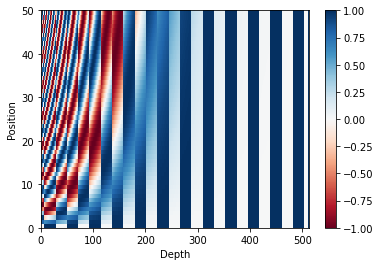

In [ ]:
pos_encoding = positional_encoding(50, 512)
print (pos_encoding.shape)

plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### Masking

Mask all the pad tokens in the batch of sequence. It ensures that the model does not treat padding as the input. The mask indicates where pad value `0` is present: it outputs a `1` at those locations, and a `0` otherwise.

In [ ]:
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
  
  # add extra dimensions to add the padding
  # to the attention logits.
  return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

In [ ]:
x = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0], [0, 0, 0, 4, 5]])
create_padding_mask(x)

<tf.Tensor: shape=(3, 1, 1, 5), dtype=float32, numpy=
array([[[[0., 0., 1., 1., 0.]]],


       [[[0., 0., 0., 1., 1.]]],


       [[[1., 1., 1., 0., 0.]]]], dtype=float32)>

The look-ahead mask is used to mask the future tokens in a sequence. In other words, the mask indicates which entries should not be used.

This means that to predict the third word, only the first and second word will be used. Similarly to predict the fourth word, only the first, second and the third word will be used and so on.

In [ ]:
def create_look_ahead_mask(size):
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
  return mask  # (seq_len, seq_len)

In [ ]:
x = tf.random.uniform((1, 3))
temp = create_look_ahead_mask(x.shape[1])
temp

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]], dtype=float32)>

### Scaled dot product attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/scaled_attention.png" width="500" alt="scaled_dot_product_attention">

The attention function used by the transformer takes three inputs: Q (query), K (key), V (value). The equation used to calculate the attention weights is:

$$\Large{Attention(Q, K, V) = softmax_k(\frac{QK^T}{\sqrt{d_k}}) V} $$

The dot-product attention is scaled by a factor of square root of the depth. This is done because for large values of depth, the dot product grows large in magnitude pushing the softmax function where it has small gradients resulting in a very hard softmax. 

For example, consider that `Q` and `K` have a mean of 0 and variance of 1. Their matrix multiplication will have a mean of 0 and variance of `dk`. Hence, *square root of `dk`* is used for scaling (and not any other number) because the matmul of `Q` and `K` should have a mean of 0 and variance of 1, and you get a gentler softmax.

The mask is multiplied with -1e9 (close to negative infinity). This is done because the mask is summed with the scaled matrix multiplication of Q and K and is applied immediately before a softmax. The goal is to zero out these cells, and large negative inputs to softmax are near zero in the output.

In [ ]:
def scaled_dot_product_attention(q, k, v, mask):
  """Calculate the attention weights.
  q, k, v must have matching leading dimensions.
  k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
  The mask has different shapes depending on its type(padding or look ahead) 
  but it must be broadcastable for addition.
  
  Args:
    q: query shape == (..., seq_len_q, depth)
    k: key shape == (..., seq_len_k, depth)
    v: value shape == (..., seq_len_v, depth_v)
    mask: Float tensor with shape broadcastable 
          to (..., seq_len_q, seq_len_k). Defaults to None.
    
  Returns:
    output, attention_weights
  """

  matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)
  
  # scale matmul_qk
  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  # add the mask to the scaled tensor.
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)  

  # softmax is normalized on the last axis (seq_len_k) so that the scores
  # add up to 1.
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

  output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

  return output, attention_weights

As the softmax normalization is done on K, its values decide the amount of importance given to Q.

The output represents the multiplication of the attention weights and the V (value) vector. This ensures that the words you want to focus on are kept as-is and the irrelevant words are flushed out.

In [ ]:
def print_out(q, k, v):
  temp_out, temp_attn = scaled_dot_product_attention(
      q, k, v, None)
  print ('Attention weights are:')
  print (temp_attn)
  print ('Output is:')
  print (temp_out)

In [ ]:
np.set_printoptions(suppress=True)

temp_k = tf.constant([[10,0,0],
                      [0,10,0],
                      [0,0,10],
                      [0,0,10]], dtype=tf.float32)  # (4, 3)

temp_v = tf.constant([[   1,0],
                      [  10,0],
                      [ 100,5],
                      [1000,6]], dtype=tf.float32)  # (4, 2)

# This `query` aligns with the second `key`,
# so the second `value` is returned.
temp_q = tf.constant([[0, 10, 0]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Attention weights are:
tf.Tensor([[0. 1. 0. 0.]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[10.  0.]], shape=(1, 2), dtype=float32)


In [ ]:
# This query aligns with a repeated key (third and fourth), 
# so all associated values get averaged.
temp_q = tf.constant([[0, 0, 10]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Attention weights are:
tf.Tensor([[0.  0.  0.5 0.5]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[550.    5.5]], shape=(1, 2), dtype=float32)


In [ ]:
# This query aligns equally with the first and second key, 
# so their values get averaged.
temp_q = tf.constant([[10, 10, 0]], dtype=tf.float32)  # (1, 3)
print_out(temp_q, temp_k, temp_v)

Attention weights are:
tf.Tensor([[0.5 0.5 0.  0. ]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[5.5 0. ]], shape=(1, 2), dtype=float32)


Pass all the queries together.

In [ ]:
temp_q = tf.constant([[0, 0, 10], [0, 10, 0], [10, 10, 0]], dtype=tf.float32)  # (3, 3)
print_out(temp_q, temp_k, temp_v)

Attention weights are:
tf.Tensor(
[[0.  0.  0.5 0.5]
 [0.  1.  0.  0. ]
 [0.5 0.5 0.  0. ]], shape=(3, 4), dtype=float32)
Output is:
tf.Tensor(
[[550.    5.5]
 [ 10.    0. ]
 [  5.5   0. ]], shape=(3, 2), dtype=float32)


### Multi-head attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/multi_head_attention.png" width="500" alt="multi-head attention">


Multi-head attention consists of four parts:
*    Linear layers and split into heads.
*    Scaled dot-product attention.
*    Concatenation of heads.
*    Final linear layer.

Each multi-head attention block gets three inputs; Q (query), K (key), V (value). These are put through linear (Dense) layers and split up into multiple heads. 

The `scaled_dot_product_attention` defined above is applied to each head (broadcasted for efficiency). An appropriate mask must be used in the attention step.  The attention output for each head is then concatenated (using `tf.transpose`, and `tf.reshape`) and put through a final `Dense` layer.

Instead of one single attention head, Q, K, and V are split into multiple heads because it allows the model to jointly attend to information at different positions from different representational spaces. After the split each head has a reduced dimensionality, so the total computation cost is the same as a single head attention with full dimensionality.

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model
    
    assert d_model % self.num_heads == 0
    
    self.depth = d_model // self.num_heads
    
    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)
    
    self.dense = tf.keras.layers.Dense(d_model)
        
  def split_heads(self, x, batch_size):
    """Split the last dimension into (num_heads, depth).
    Transpose the result such that the shape is (batch_size, num_heads, seq_len, depth)
    """
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])
    
  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]
    
    q = self.wq(q)  # (batch_size, seq_len, d_model)
    k = self.wk(k)  # (batch_size, seq_len, d_model)
    v = self.wv(v)  # (batch_size, seq_len, d_model)
    
    q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
    k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
    v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)
    
    # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
    # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
    scaled_attention, attention_weights = scaled_dot_product_attention(
        q, k, v, mask)
    
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

    concat_attention = tf.reshape(scaled_attention, 
                                  (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

    output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)
        
    return output, attention_weights

Create a `MultiHeadAttention` layer to try out. At each location in the sequence, `y`, the `MultiHeadAttention` runs all 8 attention heads across all other locations in the sequence, returning a new vector of the same length at each location.

In [ ]:
temp_mha = MultiHeadAttention(d_model=512, num_heads=8)
y = tf.random.uniform((1, 60, 512))  # (batch_size, encoder_sequence, d_model)
out, attn = temp_mha(y, k=y, q=y, mask=None)
out.shape, attn.shape

(TensorShape([1, 60, 512]), TensorShape([1, 8, 60, 60]))

### Point wise feed forward network

Point wise feed forward network consists of two fully-connected layers with a ReLU activation in between.

In [ ]:
def point_wise_feed_forward_network(d_model, dff):
  return tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
      tf.keras.layers.Dense(d_model)  # (batch_size, seq_len, d_model)
  ])

In [ ]:
sample_ffn = point_wise_feed_forward_network(512, 2048)
sample_ffn(tf.random.uniform((64, 50, 512))).shape

TensorShape([64, 50, 512])

### Encoder and decoder

<img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png" width="600" alt="transformer">

The transformer model follows the same general pattern as a standard [sequence to sequence with attention model](nmt_with_attention.ipynb). 

* The input sentence is passed through `N` encoder layers that generates an output for each word/token in the sequence.
* The decoder attends on the encoder's output and its own input (self-attention) to predict the next word. 

### Encoder layer

Each encoder layer consists of sublayers:

1.   Multi-head attention (with padding mask) 
2.    Point wise feed forward networks. 

Each of these sublayers has a residual connection around it followed by a layer normalization. Residual connections help in avoiding the vanishing gradient problem in deep networks.

The output of each sublayer is `LayerNorm(x + Sublayer(x))`. The normalization is done on the `d_model` (last) axis. There are N encoder layers in the transformer.

In [ ]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()

    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    
  def call(self, x, training, mask):

    attn_output, _ = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)
    
    ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
    ffn_output = self.dropout2(ffn_output, training=training)
    out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)
    
    return out2

In [ ]:
sample_encoder_layer = EncoderLayer(512, 8, 2048)

sample_encoder_layer_output = sample_encoder_layer(
    tf.random.uniform((64, 43, 512)), False, None)

sample_encoder_layer_output.shape  # (batch_size, input_seq_len, d_model)

TensorShape([64, 43, 512])

### Decoder layer

Each decoder layer consists of sublayers:

1.   Masked multi-head attention (with look ahead mask and padding mask)
2.   Multi-head attention (with padding mask). V (value) and K (key) receive the *encoder output* as inputs. Q (query) receives the *output from the masked multi-head attention sublayer.*
3.   Point wise feed forward networks

Each of these sublayers has a residual connection around it followed by a layer normalization. The output of each sublayer is `LayerNorm(x + Sublayer(x))`. The normalization is done on the `d_model` (last) axis.

There are N decoder layers in the transformer.

As Q receives the output from decoder's first attention block, and K receives the encoder output, the attention weights represent the importance given to the decoder's input based on the encoder's output. In other words, the decoder predicts the next word by looking at the encoder output and self-attending to its own output. See the demonstration above in the scaled dot product attention section.

In [ ]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(DecoderLayer, self).__init__()

    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)

    self.ffn = point_wise_feed_forward_network(d_model, dff)
 
    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    
    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    self.dropout3 = tf.keras.layers.Dropout(rate)
    
    
  def call(self, x, enc_output, training, 
           look_ahead_mask, padding_mask):
    # enc_output.shape == (batch_size, input_seq_len, d_model)

    attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)  # (batch_size, target_seq_len, d_model)
    attn1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(attn1 + x)
    
    attn2, attn_weights_block2 = self.mha2(
        enc_output, enc_output, out1, padding_mask)  # (batch_size, target_seq_len, d_model)
    attn2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(attn2 + out1)  # (batch_size, target_seq_len, d_model)
    
    ffn_output = self.ffn(out2)  # (batch_size, target_seq_len, d_model)
    ffn_output = self.dropout3(ffn_output, training=training)
    out3 = self.layernorm3(ffn_output + out2)  # (batch_size, target_seq_len, d_model)
    
    return out3, attn_weights_block1, attn_weights_block2

In [ ]:
sample_decoder_layer = DecoderLayer(512, 8, 2048)

sample_decoder_layer_output, _, _ = sample_decoder_layer(
    tf.random.uniform((64, 50, 512)), sample_encoder_layer_output, 
    False, None, None)

sample_decoder_layer_output.shape  # (batch_size, target_seq_len, d_model)

TensorShape([64, 50, 512])

### Encoder

The `Encoder` consists of:
1.   Input Embedding
2.   Positional Encoding
3.   N encoder layers

The input is put through an embedding which is summed with the positional encoding. The output of this summation is the input to the encoder layers. The output of the encoder is the input to the decoder.

In [ ]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Encoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers
    
    self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, 
                                            self.d_model)
    
    
    self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) 
                       for _ in range(num_layers)]
  
    self.dropout = tf.keras.layers.Dropout(rate)
        
  def call(self, x, training, mask):

    seq_len = tf.shape(x)[1]
    
    # adding embedding and position encoding.
    x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]

    x = self.dropout(x, training=training)
    
    for i in range(self.num_layers):
      x = self.enc_layers[i](x, training, mask)
    
    return x  # (batch_size, input_seq_len, d_model)

In [ ]:
sample_encoder = Encoder(num_layers=2, d_model=512, num_heads=8, 
                         dff=2048, input_vocab_size=8500,
                         maximum_position_encoding=10000)
temp_input = tf.random.uniform((64, 62), dtype=tf.int64, minval=0, maxval=200)

sample_encoder_output = sample_encoder(temp_input, training=False, mask=None)

print (sample_encoder_output.shape)  # (batch_size, input_seq_len, d_model)

(64, 62, 512)


### Decoder

 The `Decoder` consists of:
1.   Output Embedding
2.   Positional Encoding
3.   N decoder layers

The target is put through an embedding which is summed with the positional encoding. The output of this summation is the input to the decoder layers. The output of the decoder is the input to the final linear layer.

In [ ]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers
    
    self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
    
    self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) 
                       for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(rate)
    
  def call(self, x, enc_output, training, 
           look_ahead_mask, padding_mask):

    seq_len = tf.shape(x)[1]
    attention_weights = {}
    
    x = self.embedding(x)  # (batch_size, target_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]
    
    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x, block1, block2 = self.dec_layers[i](x, enc_output, training,
                                             look_ahead_mask, padding_mask)
      
      attention_weights['decoder_layer{}_block1'.format(i+1)] = block1
      attention_weights['decoder_layer{}_block2'.format(i+1)] = block2
    
    # x.shape == (batch_size, target_seq_len, d_model)
    return x, attention_weights

In [ ]:
sample_decoder = Decoder(num_layers=2, d_model=512, num_heads=8, 
                         dff=2048, target_vocab_size=8000,
                         maximum_position_encoding=5000)
temp_input = tf.random.uniform((64, 26), dtype=tf.int64, minval=0, maxval=200)

output, attn = sample_decoder(temp_input, 
                              enc_output=sample_encoder_output, 
                              training=False,
                              look_ahead_mask=None, 
                              padding_mask=None)

output.shape, attn['decoder_layer2_block2'].shape

(TensorShape([64, 26, 512]), TensorShape([64, 8, 26, 62]))

### Create the Transformer

Transformer consists of the encoder, decoder and a final linear layer. The output of the decoder is the input to the linear layer and its output is returned.

In [ ]:
class Transformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, 
               target_vocab_size, pe_input, pe_target, rate=0.1):
    super(Transformer, self).__init__()

    self.encoder = Encoder(num_layers, d_model, num_heads, dff, 
                           input_vocab_size, pe_input, rate)

    self.decoder = Decoder(num_layers, d_model, num_heads, dff, 
                           target_vocab_size, pe_target, rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)
    
  def call(self, inp, tar, training, enc_padding_mask, 
           look_ahead_mask, dec_padding_mask):

    enc_output = self.encoder(inp, training, enc_padding_mask)  # (batch_size, inp_seq_len, d_model)
    
    # dec_output.shape == (batch_size, tar_seq_len, d_model)
    dec_output, attention_weights = self.decoder(
        tar, enc_output, training, look_ahead_mask, dec_padding_mask)
    
    final_output = self.final_layer(dec_output)  # (batch_size, tar_seq_len, target_vocab_size)
    
    return final_output, attention_weights

In [ ]:
sample_transformer = Transformer(
    num_layers=2, d_model=512, num_heads=8, dff=2048, 
    input_vocab_size=8500, target_vocab_size=8000, 
    pe_input=10000, pe_target=6000)

temp_input = tf.random.uniform((64, 38), dtype=tf.int64, minval=0, maxval=200)
temp_target = tf.random.uniform((64, 36), dtype=tf.int64, minval=0, maxval=200)

fn_out, _ = sample_transformer(temp_input, temp_target, training=False, 
                               enc_padding_mask=None, 
                               look_ahead_mask=None,
                               dec_padding_mask=None)

fn_out.shape  # (batch_size, tar_seq_len, target_vocab_size)

TensorShape([64, 36, 8000])

### Set hyperparameters

To keep this example small and relatively fast, the values for *num_layers, d_model, and dff* have been reduced. 

The values used in the base model of transformer were; *num_layers=6*, *d_model = 512*, *dff = 2048*. See the [paper](https://arxiv.org/abs/1706.03762) for all the other versions of the transformer.

Note: By changing the values below, you can get the model that achieved state of the art on many tasks.

In [ ]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8

input_vocab_size = tokenizer_pt.vocab_size + 2
target_vocab_size = tokenizer_en.vocab_size + 2
dropout_rate = 0.1

### Optimizer

Use the Adam optimizer with a custom learning rate scheduler according to the formula in the [paper](https://arxiv.org/abs/1706.03762).

$$\Large{lrate = d_{model}^{-0.5} * min(step{\_}num^{-0.5}, step{\_}num * warmup{\_}steps^{-1.5})}$$


In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()
    
    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps
    
  def __call__(self, step):
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)
    
    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [ ]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, 
                                     epsilon=1e-9)

Text(0.5, 0, 'Train Step')

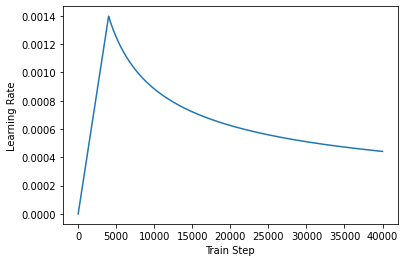

In [ ]:
temp_learning_rate_schedule = CustomSchedule(d_model)

plt.plot(temp_learning_rate_schedule(tf.range(40000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

### Loss and metrics

Since the target sequences are padded, it is important to apply a padding mask when calculating the loss.

In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

In [ ]:
def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask
  
  return tf.reduce_sum(loss_)/tf.reduce_sum(mask)

In [ ]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
    name='train_accuracy')

### Training and checkpointing

In [ ]:
transformer = Transformer(num_layers, d_model, num_heads, dff,
                          input_vocab_size, target_vocab_size, 
                          pe_input=input_vocab_size, 
                          pe_target=target_vocab_size,
                          rate=dropout_rate)

In [ ]:
def create_masks(inp, tar):
  # Encoder padding mask
  enc_padding_mask = create_padding_mask(inp)
  
  # Used in the 2nd attention block in the decoder.
  # This padding mask is used to mask the encoder outputs.
  dec_padding_mask = create_padding_mask(inp)
  
  # Used in the 1st attention block in the decoder.
  # It is used to pad and mask future tokens in the input received by 
  # the decoder.
  look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
  dec_target_padding_mask = create_padding_mask(tar)
  combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
  
  return enc_padding_mask, combined_mask, dec_padding_mask

Create the checkpoint path and the checkpoint manager. This will be used to save checkpoints every `n` epochs.

In [ ]:
checkpoint_path = "./checkpoints/train"

ckpt = tf.train.Checkpoint(transformer=transformer,
                           optimizer=optimizer)

ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# if a checkpoint exists, restore the latest checkpoint.
if ckpt_manager.latest_checkpoint:
  ckpt.restore(ckpt_manager.latest_checkpoint)
  print ('Latest checkpoint restored!!')

The target is divided into tar_inp and tar_real. tar_inp is passed as an input to the decoder. `tar_real` is that same input shifted by 1: At each location in `tar_input`, `tar_real` contains the  next token that should be predicted.

For example, `sentence` = "SOS A lion in the jungle is sleeping EOS"

`tar_inp` =  "SOS A lion in the jungle is sleeping"

`tar_real` = "A lion in the jungle is sleeping EOS"

The transformer is an auto-regressive model: it makes predictions one part at a time, and uses its output so far to decide what to do next. 

During training this example uses teacher-forcing (like in the [text generation tutorial](./text_generation.ipynb)). Teacher forcing is passing the true output to the next time step regardless of what the model predicts at the current time step.

As the transformer predicts each word, *self-attention* allows it to look at the previous words in the input sequence to better predict the next word.

To prevent the model from peeking at the expected output the model uses a look-ahead mask.

In [ ]:
EPOCHS = 20

In [ ]:
# The @tf.function trace-compiles train_step into a TF graph for faster
# execution. The function specializes to the precise shape of the argument
# tensors. To avoid re-tracing due to the variable sequence lengths or variable
# batch sizes (the last batch is smaller), use input_signature to specify
# more generic shapes.

train_step_signature = [
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
]

@tf.function(input_signature=train_step_signature)
def train_step(inp, tar):
  tar_inp = tar[:, :-1]
  tar_real = tar[:, 1:]
  
  enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)
  
  with tf.GradientTape() as tape:
    predictions, _ = transformer(inp, tar_inp, 
                                 True, 
                                 enc_padding_mask, 
                                 combined_mask, 
                                 dec_padding_mask)
    loss = loss_function(tar_real, predictions)

  gradients = tape.gradient(loss, transformer.trainable_variables)    
  optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))
  
  train_loss(loss)
  train_accuracy(tar_real, predictions)

Portuguese is used as the input language and English is the target language.

In [ ]:
for epoch in range(EPOCHS):
  start = time.time()
  
  train_loss.reset_states()
  train_accuracy.reset_states()
  
  # inp -> portuguese, tar -> english
  for (batch, (inp, tar)) in enumerate(train_dataset):
    train_step(inp, tar)
    
    if batch % 50 == 0:
      print ('Epoch {} Batch {} Loss {:.4f} Accuracy {:.4f}'.format(
          epoch + 1, batch, train_loss.result(), train_accuracy.result()))
      
  if (epoch + 1) % 5 == 0:
    ckpt_save_path = ckpt_manager.save()
    print ('Saving checkpoint for epoch {} at {}'.format(epoch+1,
                                                         ckpt_save_path))
    
  print ('Epoch {} Loss {:.4f} Accuracy {:.4f}'.format(epoch + 1, 
                                                train_loss.result(), 
                                                train_accuracy.result()))

  print ('Time taken for 1 epoch: {} secs\n'.format(time.time() - start))

Epoch 1 Batch 0 Loss 8.9950 Accuracy 0.0004
Epoch 1 Batch 50 Loss 8.9483 Accuracy 0.0020
Epoch 1 Batch 100 Loss 8.8548 Accuracy 0.0129
Epoch 1 Batch 150 Loss 8.7534 Accuracy 0.0175
Epoch 1 Batch 200 Loss 8.6268 Accuracy 0.0199
Epoch 1 Batch 250 Loss 8.4743 Accuracy 0.0213
Epoch 1 Batch 300 Loss 8.3000 Accuracy 0.0222
Epoch 1 Batch 350 Loss 8.1148 Accuracy 0.0252
Epoch 1 Batch 400 Loss 7.9316 Accuracy 0.0285
Epoch 1 Batch 450 Loss 7.7665 Accuracy 0.0317
Epoch 1 Batch 500 Loss 7.6198 Accuracy 0.0353
Epoch 1 Batch 550 Loss 7.4844 Accuracy 0.0394
Epoch 1 Batch 600 Loss 7.3570 Accuracy 0.0435
Epoch 1 Batch 650 Loss 7.2362 Accuracy 0.0473
Epoch 1 Batch 700 Loss 7.1195 Accuracy 0.0511
Epoch 1 Loss 7.1148 Accuracy 0.0512
Time taken for 1 epoch: 81.85551714897156 secs

Epoch 2 Batch 0 Loss 5.5560 Accuracy 0.1062
Epoch 2 Batch 50 Loss 5.4624 Accuracy 0.1048
Epoch 2 Batch 100 Loss 5.4135 Accuracy 0.1055
Epoch 2 Batch 150 Loss 5.3616 Accuracy 0.1074
Epoch 2 Batch 200 Loss 5.3105 Accuracy 0.1094
Ep

### Evaluate

The following steps are used for evaluation:

* Encode the input sentence using the Portuguese tokenizer (`tokenizer_pt`). Moreover, add the start and end token so the input is equivalent to what the model is trained with. This is the encoder input.
* The decoder input is the `start token == tokenizer_en.vocab_size`.
* Calculate the padding masks and the look ahead masks.
* The `decoder` then outputs the predictions by looking at the `encoder output` and its own output (self-attention).
* Select the last word and calculate the argmax of that.
* Concatentate the predicted word to the decoder input as pass it to the decoder.
* In this approach, the decoder predicts the next word based on the previous words it predicted.

Note: The model used here has less capacity to keep the example relatively faster so the predictions maybe less right. To reproduce the results in the paper, use the entire dataset and base transformer model or transformer XL, by changing the hyperparameters above.

In [ ]:
def evaluate(inp_sentence):
  start_token = [tokenizer_pt.vocab_size]
  end_token = [tokenizer_pt.vocab_size + 1]
  
  # inp sentence is portuguese, hence adding the start and end token
  inp_sentence = start_token + tokenizer_pt.encode(inp_sentence) + end_token
  encoder_input = tf.expand_dims(inp_sentence, 0)
  
  # as the target is english, the first word to the transformer should be the
  # english start token.
  decoder_input = [tokenizer_en.vocab_size]
  output = tf.expand_dims(decoder_input, 0)
    
  for i in range(MAX_LENGTH):
    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
        encoder_input, output)
  
    # predictions.shape == (batch_size, seq_len, vocab_size)
    predictions, attention_weights = transformer(encoder_input, 
                                                 output,
                                                 False,
                                                 enc_padding_mask,
                                                 combined_mask,
                                                 dec_padding_mask)
    
    # select the last word from the seq_len dimension
    predictions = predictions[: ,-1:, :]  # (batch_size, 1, vocab_size)

    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)
    
    # return the result if the predicted_id is equal to the end token
    if predicted_id == tokenizer_en.vocab_size+1:
      return tf.squeeze(output, axis=0), attention_weights
    
    # concatentate the predicted_id to the output which is given to the decoder
    # as its input.
    output = tf.concat([output, predicted_id], axis=-1)

  return tf.squeeze(output, axis=0), attention_weights

In [ ]:
def plot_attention_weights(attention, sentence, result, layer):
  fig = plt.figure(figsize=(16, 8))
  
  sentence = tokenizer_pt.encode(sentence)
  
  attention = tf.squeeze(attention[layer], axis=0)
  
  for head in range(attention.shape[0]):
    ax = fig.add_subplot(2, 4, head+1)
    
    # plot the attention weights
    ax.matshow(attention[head][:-1, :], cmap='viridis')

    fontdict = {'fontsize': 10}
    
    ax.set_xticks(range(len(sentence)+2))
    ax.set_yticks(range(len(result)))
    
    ax.set_ylim(len(result)-1.5, -0.5)
        
    ax.set_xticklabels(
        ['<start>']+[tokenizer_pt.decode([i]) for i in sentence]+['<end>'], 
        fontdict=fontdict, rotation=90)
    
    ax.set_yticklabels([tokenizer_en.decode([i]) for i in result 
                        if i < tokenizer_en.vocab_size], 
                       fontdict=fontdict)
    
    ax.set_xlabel('Head {}'.format(head+1))
  
  plt.tight_layout()
  plt.show()

In [ ]:
def translate(sentence, plot=''):
  result, attention_weights = evaluate(sentence)
  
  predicted_sentence = tokenizer_en.decode([i for i in result 
                                            if i < tokenizer_en.vocab_size])  

  print('Input: {}'.format(sentence))
  print('Predicted translation: {}'.format(predicted_sentence))
  
  if plot:
    plot_attention_weights(attention_weights, sentence, result, plot)

In [ ]:
translate("este é um problema que temos que resolver.")
print ("Real translation: this is a problem we have to solve .")

Input: este é um problema que temos que resolver.
Predicted translation: this is a problem we have to solve it .
Real translation: this is a problem we have to solve .


In [ ]:
translate("os meus vizinhos ouviram sobre esta ideia.")
print ("Real translation: and my neighboring homes heard about this idea .")

Input: os meus vizinhos ouviram sobre esta ideia.
Predicted translation: my neighbors heard about this idea .
Real translation: and my neighboring homes heard about this idea .


In [ ]:
translate("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.")
print ("Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .")

Input: vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Predicted translation: so i 'm going to very quickly to share with you some of the magic stories that have happened .
Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .


You can pass different layers and attention blocks of the decoder to the `plot` parameter.

Input: este é o primeiro livro que eu fiz.
Predicted translation: this is the first book i made .


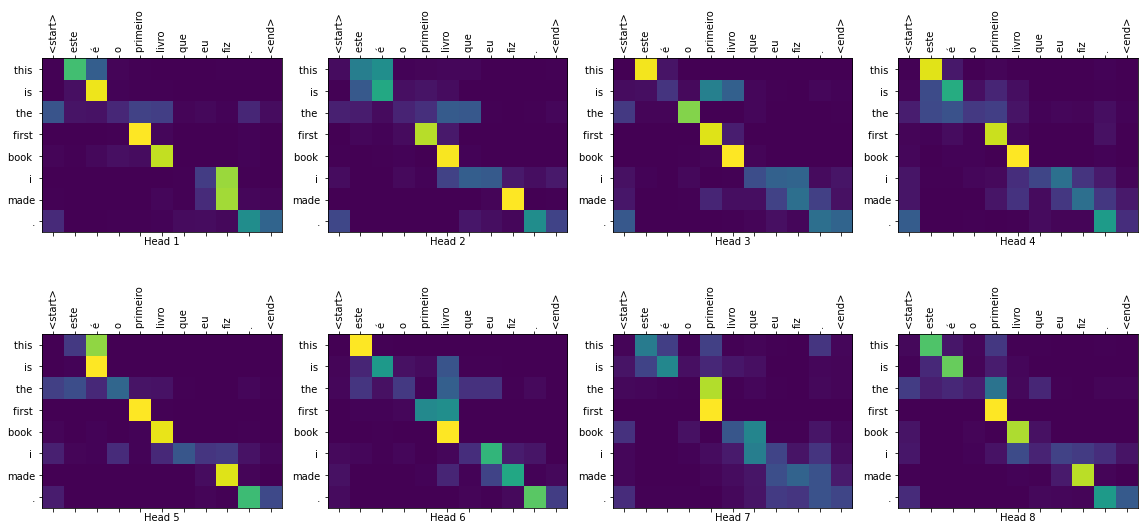

Real translation: this is the first book i've ever done.


In [ ]:
translate("este é o primeiro livro que eu fiz.", plot='decoder_layer4_block2')
print ("Real translation: this is the first book i've ever done.")

### Summary

In this tutorial, you learned about positional encoding, multi-head attention, the importance of masking and how to create a transformer.

Try using a different dataset to train the transformer. You can also create the base transformer or transformer XL by changing the hyperparameters above. You can also use the layers defined here to create [BERT](https://arxiv.org/abs/1810.04805) and train state of the art models. Futhermore, you can implement beam search to get better predictions.